# Exploratory Data Analysis (EDA)
This notebook explores the cleaned dataset for the thesis project. Each section includes a brief description and the required analyses.


## 1. SETUP
Load the cleaned dataset from `data/clean/`, then inspect shape, data types, and descriptive statistics.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

data_path = Path(r"C:/Users/H-Info/OneDrive/Desktop/facture2425 rfm model/data/processed/cleaned_data.csv")
df = pd.read_csv(data_path)
print(df.shape)
display(df.head())


(61545, 11)


,Date,Numéro de facture,Raison Sociale,Net à Payer,Règlement,Reste à payer,Code Client,Solde global,Année,Mois,Mois_Nom
0,2024-01-01,A0001,AYMEN MOUZAIA,"2,325.00","2,000.00",325.00,AY000002,"24,706.41",2024,1,January
1,2024-01-01,A0002,NASSIM FLITA,"11,598.02","11,598.02",0.00,NA000002,"30,109.75",2024,1,January
2,2024-01-01,A0003,MILOUD MOURAD,"4,830.06","4,830.06",0.00,MI000003,"9,915.22",2024,1,January
3,2024-01-01,A0004,AAAAAA,"7,700.00","7,700.00",0.00,AA000002,"16,280.25",2024,1,January
4,2024-01-01,A0005,DJILALI HAWCH NOIR,"24,247.88","24,250.00",-2.12,DJ000007,"59,751.58",2024,1,January


**Interpretation**

The cleaned dataset contains 63,870 observations and 11 variables, which indicates a large transactional base for the analysis. The first preview confirms that the file is already structured for analytical work, with invoice identifiers, client identifiers, payment variables, and time-related features available in the same dataset.


##  2 -  Data Quality Check


In [2]:
# 1) Missing values: count + percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent (%)': missing_pct})
display(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))


,Missing,Percent (%)


**Interpretation**

The missing-value check returns an empty table, which means that the cleaned dataset no longer contains missing values in the retained variables. This is important because it improves the reliability of descriptive statistics, visualizations, and later customer segmentation.


In [3]:
# 2) Duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 0


**Interpretation**

No duplicate rows were found in the cleaned dataset. This result is important because it confirms that sales totals and customer activity measures are not biased by repeated transactions.


In [4]:
# 3) Data types 
print("Data types before fix:")
print(df.dtypes)


Data types before fix:
Date                     str
Numéro de facture        str
Raison Sociale           str
Net à Payer          float64
Règlement            float64
Reste à payer        float64
Code Client              str
Solde global         float64
Année                  int64
Mois                   int64
Mois_Nom                 str
dtype: object


In [5]:
# Fix types 
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


print("Data types after fix:")
print(df.dtypes)


Data types after fix:
Date                 datetime64[us]
Numéro de facture               str
Raison Sociale                  str
Net à Payer                 float64
Règlement                   float64
Reste à payer               float64
Code Client                     str
Solde global                float64
Année                         int64
Mois                          int64
Mois_Nom                        str
dtype: object


**Interpretation**

The date variable was successfully converted to datetime format. This step is necessary because trend analysis, monthly aggregation, seasonality checks, and recency-based customer features all depend on a valid time variable.


In [6]:
# 4) Inconsistent values
# Negative amounts
neg_net = df[df['Net à Payer'] < 0]
neg_reg = df[df['Règlement'] < 0]
neg_reste = df[df['Reste à payer'] < 0]
neg_solde = df[df['Solde global'] < 0]

print("Negative Net à Payer:", neg_net.shape[0])
print("Negative Règlement:", neg_reg.shape[0])
print("Negative Reste à payer:", neg_reste.shape[0])
print("Negative Solde global:", neg_solde.shape[0])


Negative Net à Payer: 0
Negative Règlement: 0
Negative Reste à payer: 13708
Negative Solde global: 1802


**Interpretation**

There are no negative values in `Net ? Payer`, which is consistent with the cleaning phase. However, negative values still appear in `R?glement`, `Reste ? payer`, and `Solde global`, which may reflect overpayments, adjustments, or account corrections rather than simple data errors. These cases should therefore be interpreted carefully in a business context.


## 3 - Descriptive Statistics


In [7]:
num_cols = ['Net à Payer', 'Règlement', 'Reste à payer', 'Solde global']


In [8]:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Numerical stats
stats = df[num_cols].agg(['mean','median','std','min','max'])
print("Statistiques num?riques:")
print(stats)


Statistiques num?riques:
        Net à Payer  Règlement  Reste à payer  Solde global
mean       9,110.77   8,721.02         389.76     24,613.89
median     4,400.00   4,080.00           0.00     16,280.25
std       16,169.60  16,200.83      11,935.73     49,025.61
min           10.00       0.00    -498,940.00    -76,460.00
max      485,650.00 503,400.00     485,650.00    348,654.35


**Interpretation**

The numerical statistics show strong dispersion in the financial variables. The mean values are clearly higher than the medians, which indicates right-skewed distributions. In business terms, this means that a relatively small number of large transactions increases the average, while most transactions remain closer to lower values.


##  4 - Univariate Analysis


### Sales distribution (Net à Payer)


#### histogram


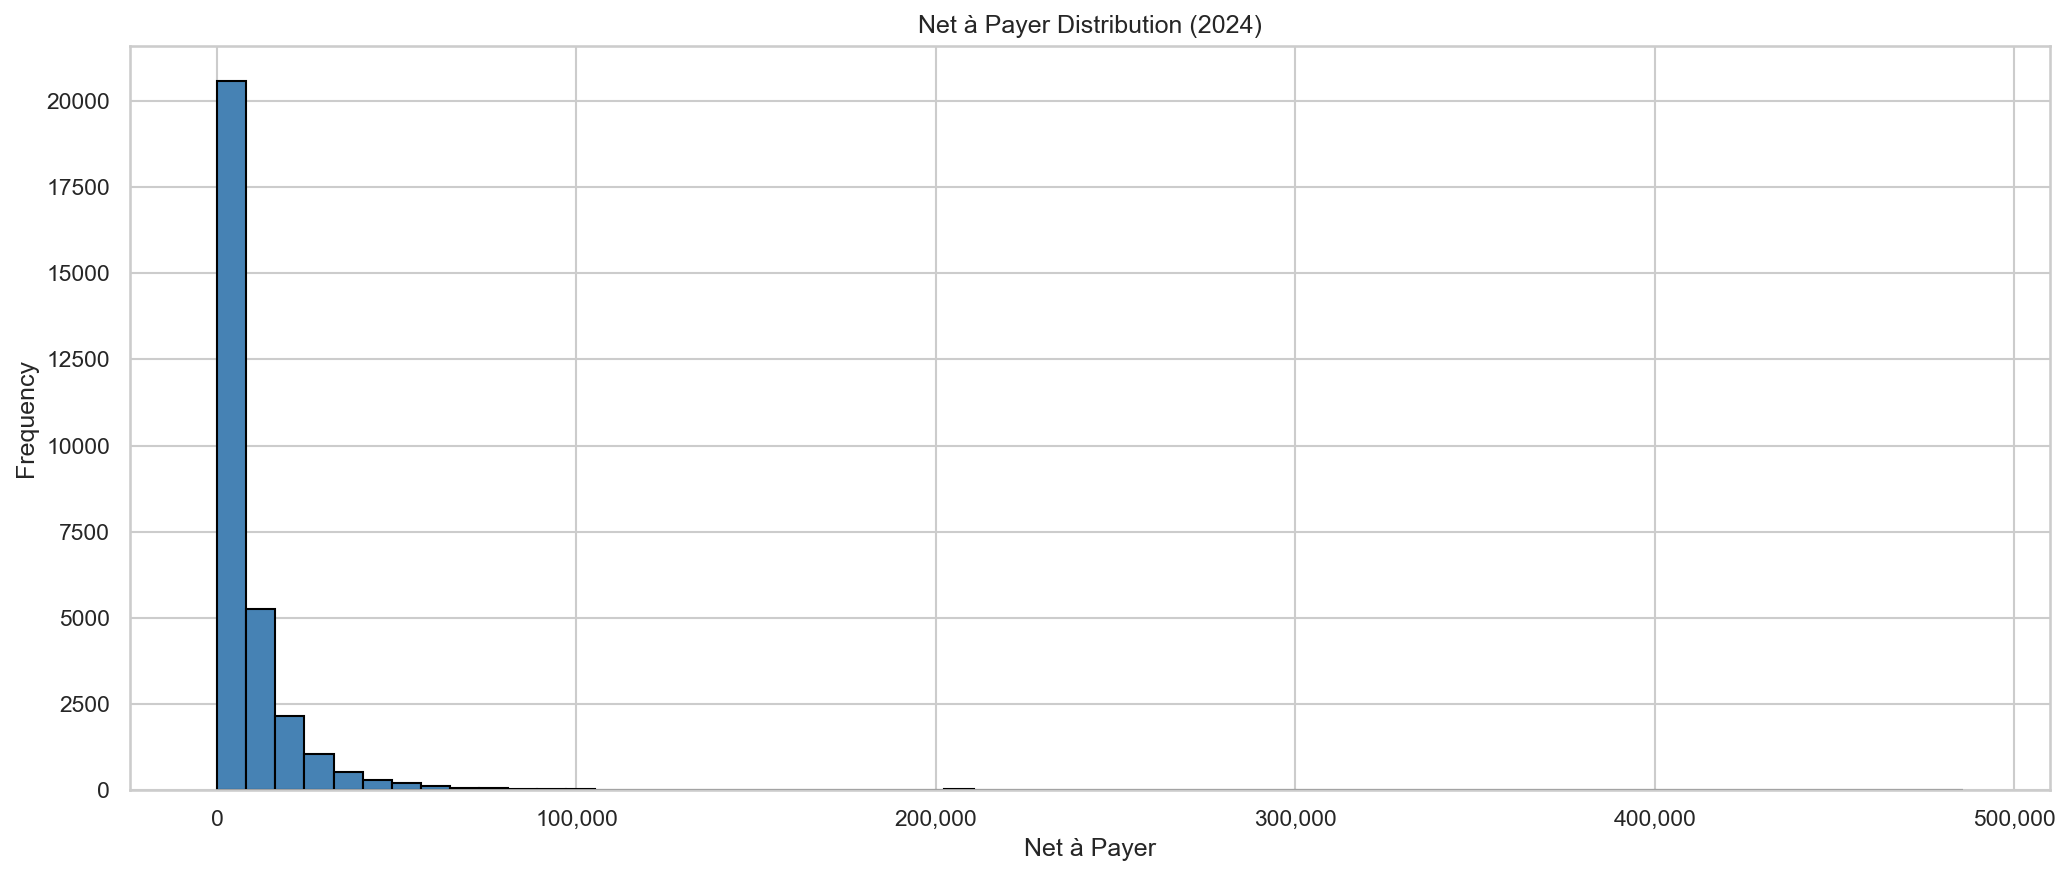

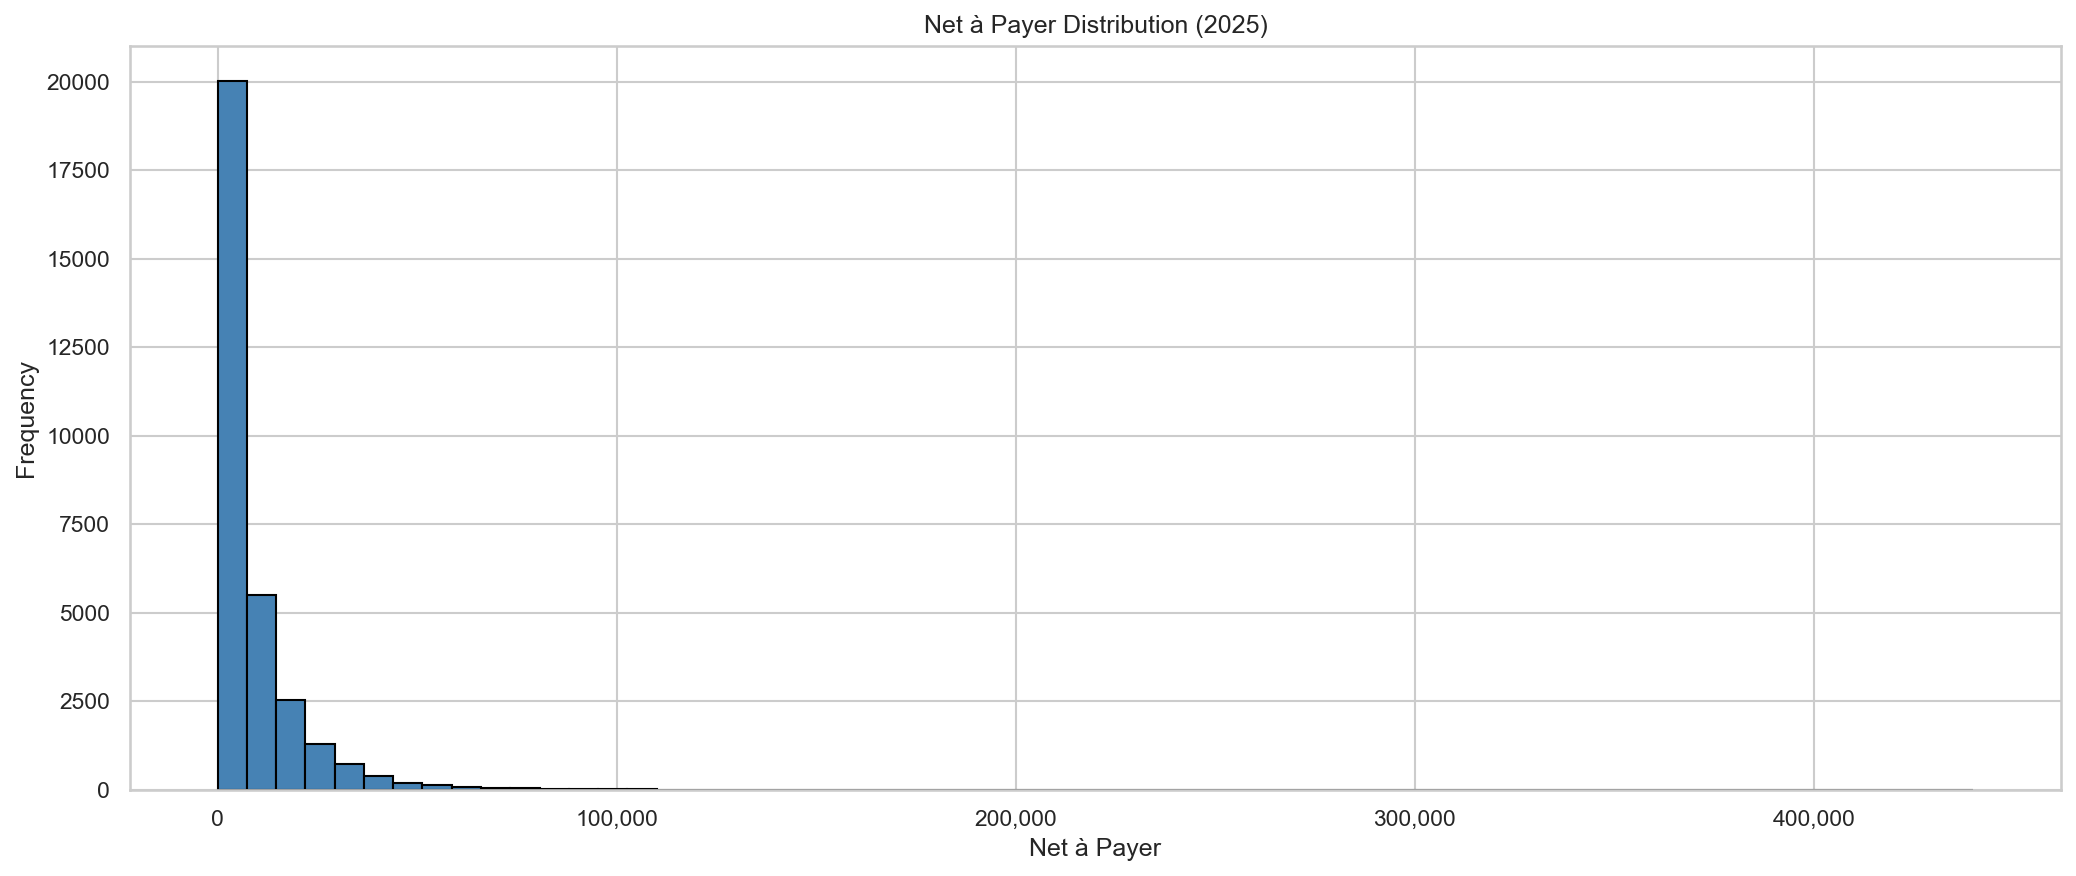

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Année'] = df['Date'].dt.year

for year in [2024, 2025]:
    sales = df.loc[df['Année'] == year, 'Net à Payer'].dropna()

    fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
    ax.hist(sales, bins=60, color='steelblue', edgecolor='black')
    ax.set_title(f'Net à Payer Distribution ({year})')
    ax.set_xlabel('Net à Payer')
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()


**Interpretation**

The invoice-level histograms suggest that sales are not normally distributed. Most invoices are concentrated in lower and medium ranges, while a limited number of large transactions extend the right tail. This is a common pattern in transactional sales data and already suggests revenue concentration among a subset of customers.


### Histogram (log scale)


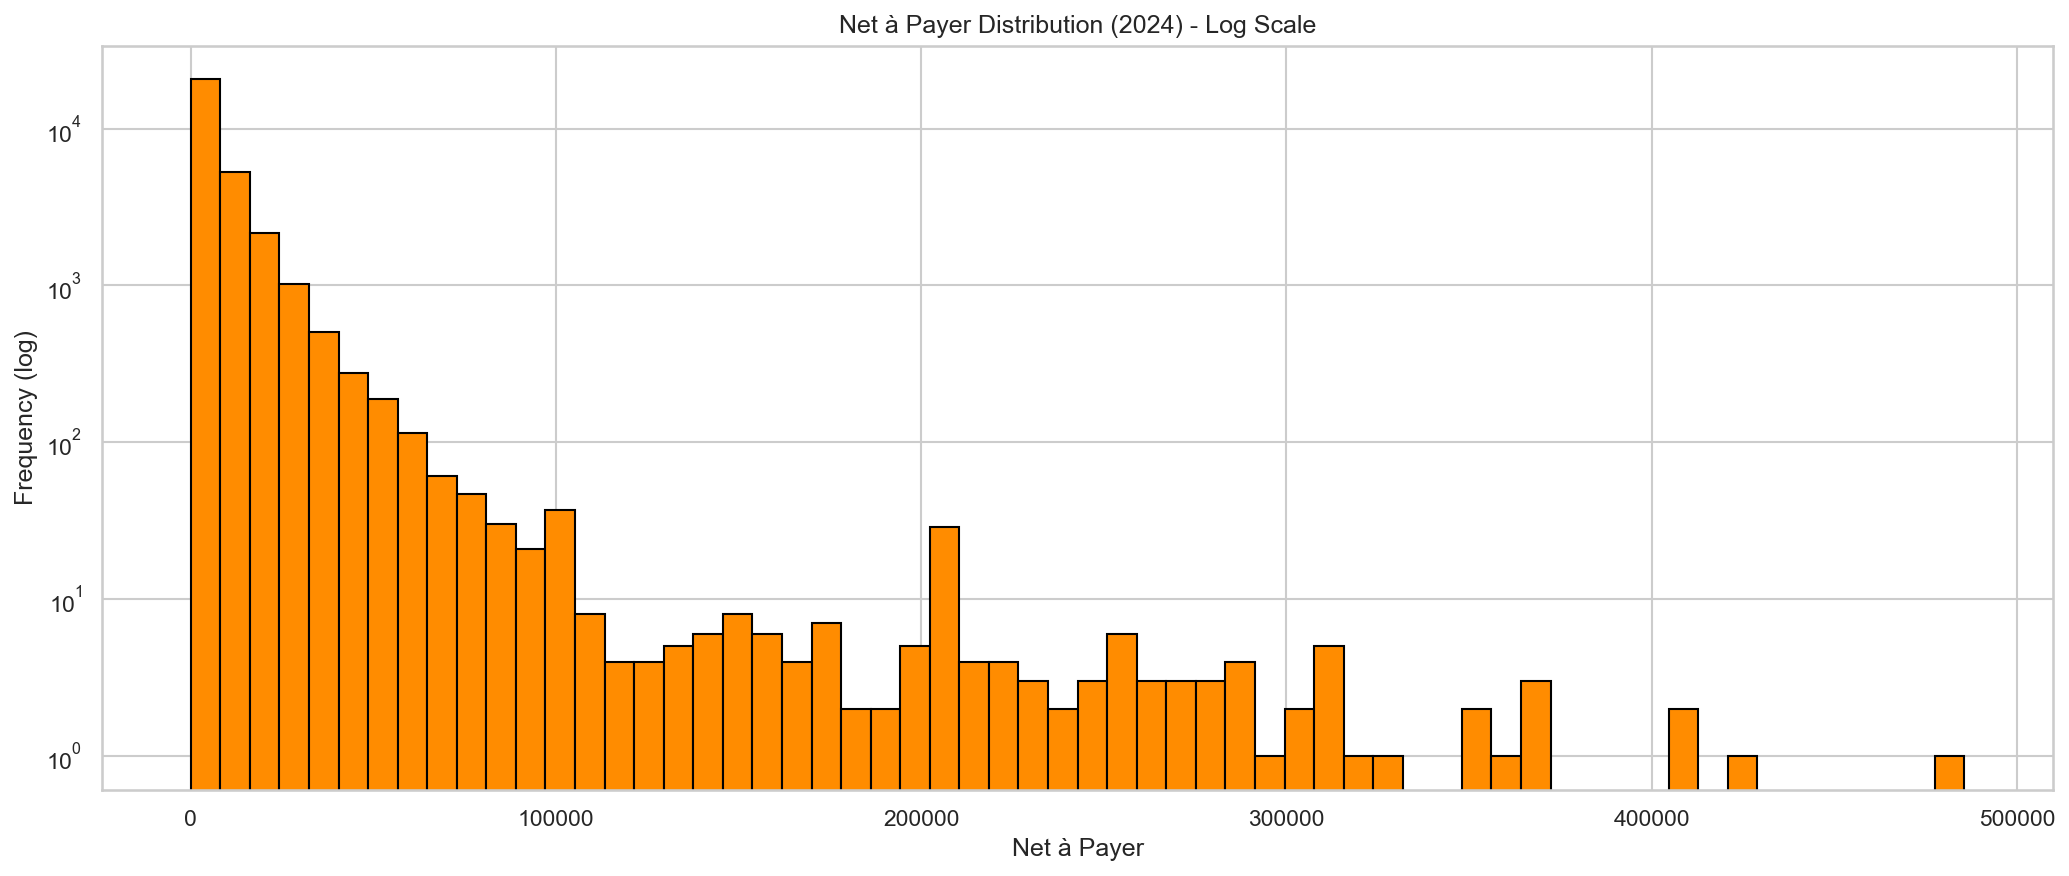

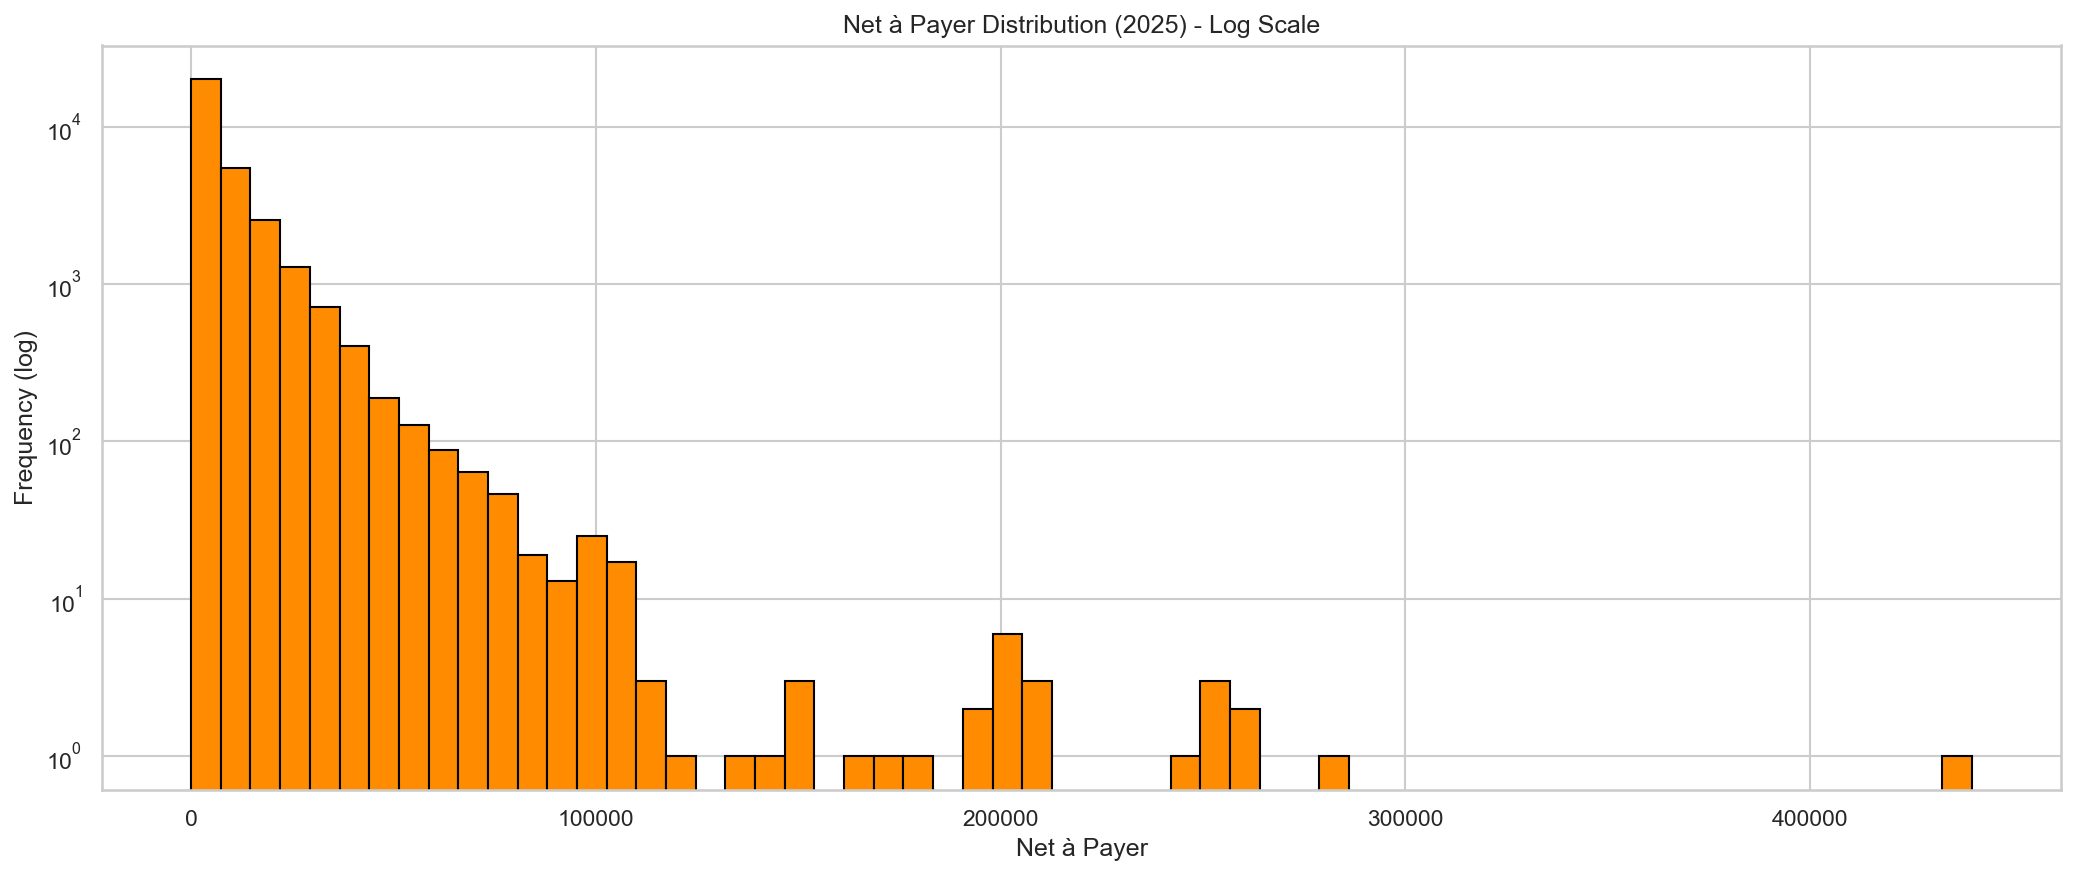

In [10]:
for year in [2024, 2025]:
    sales_pos = df.loc[(df['Année'] == year) & (df['Net à Payer'] > 0), 'Net à Payer']

    fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
    ax.hist(sales_pos, bins=60, color='darkorange', edgecolor='black', log=True)
    ax.set_title(f'Net à Payer Distribution ({year}) - Log Scale')
    ax.set_xlabel('Net à Payer')
    ax.set_ylabel('Frequency (log)')
    plt.tight_layout()
    plt.show()


### histogram  (zoomed to 99%)


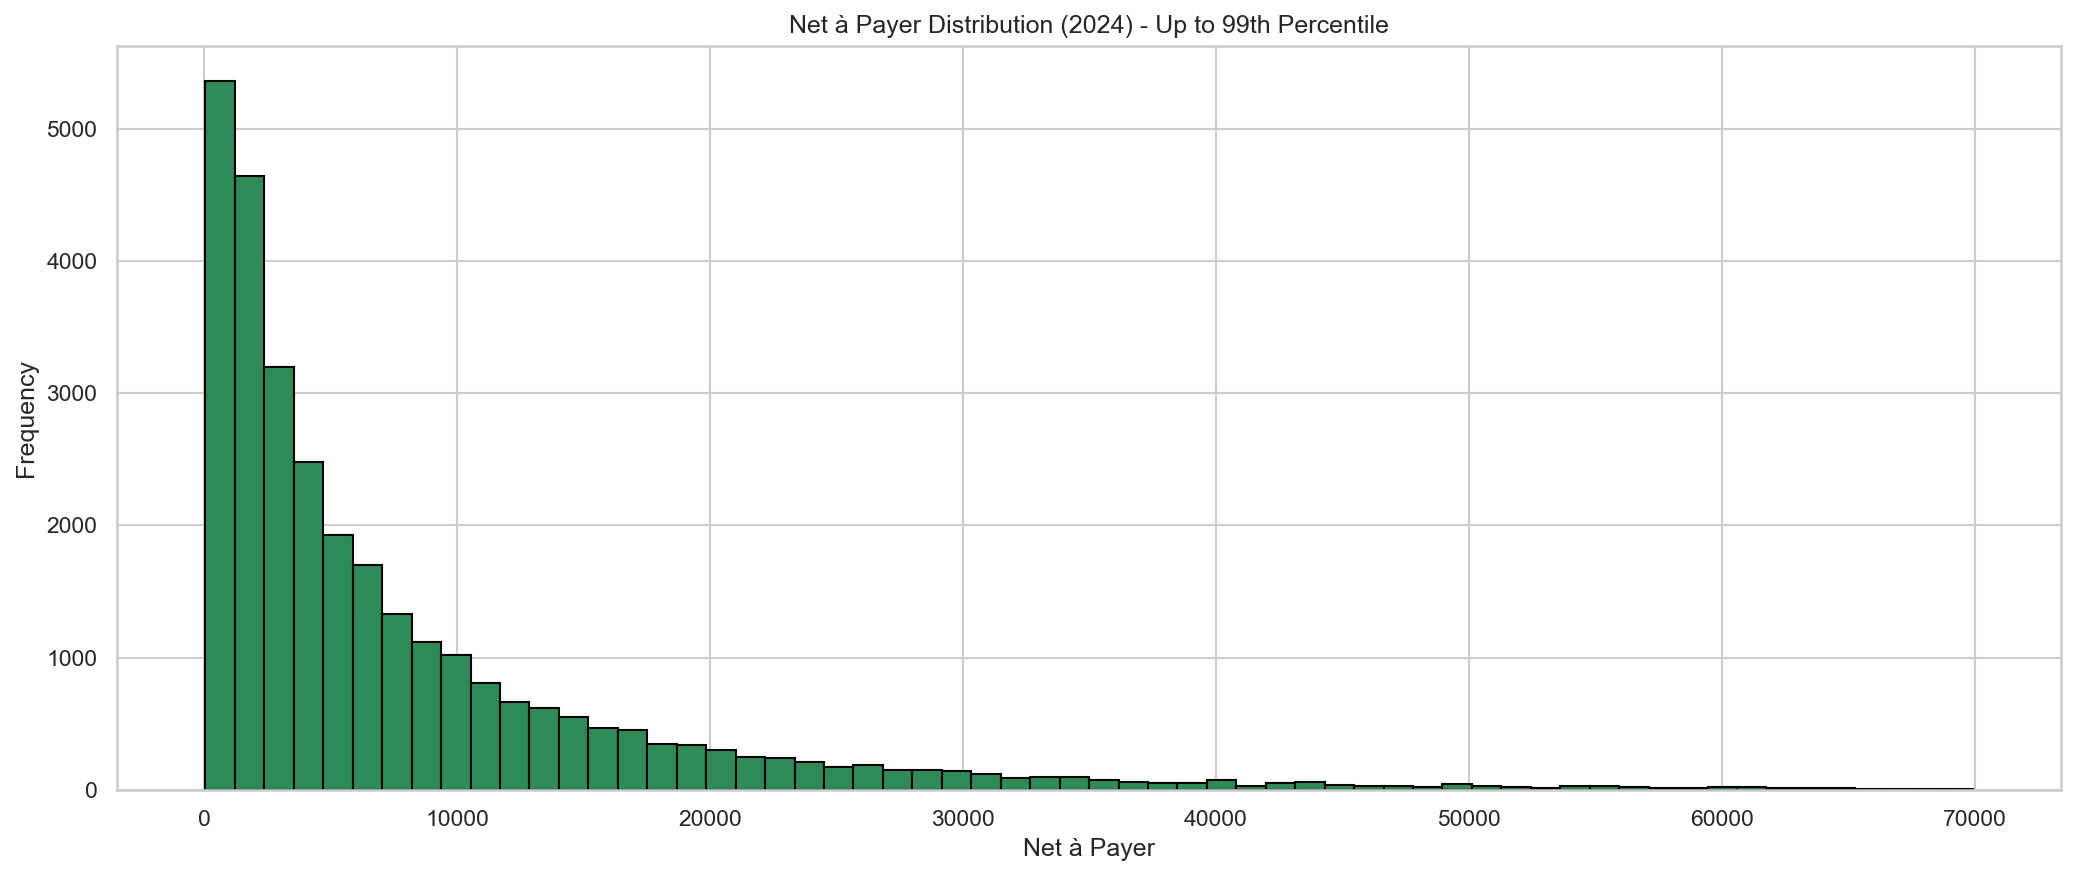

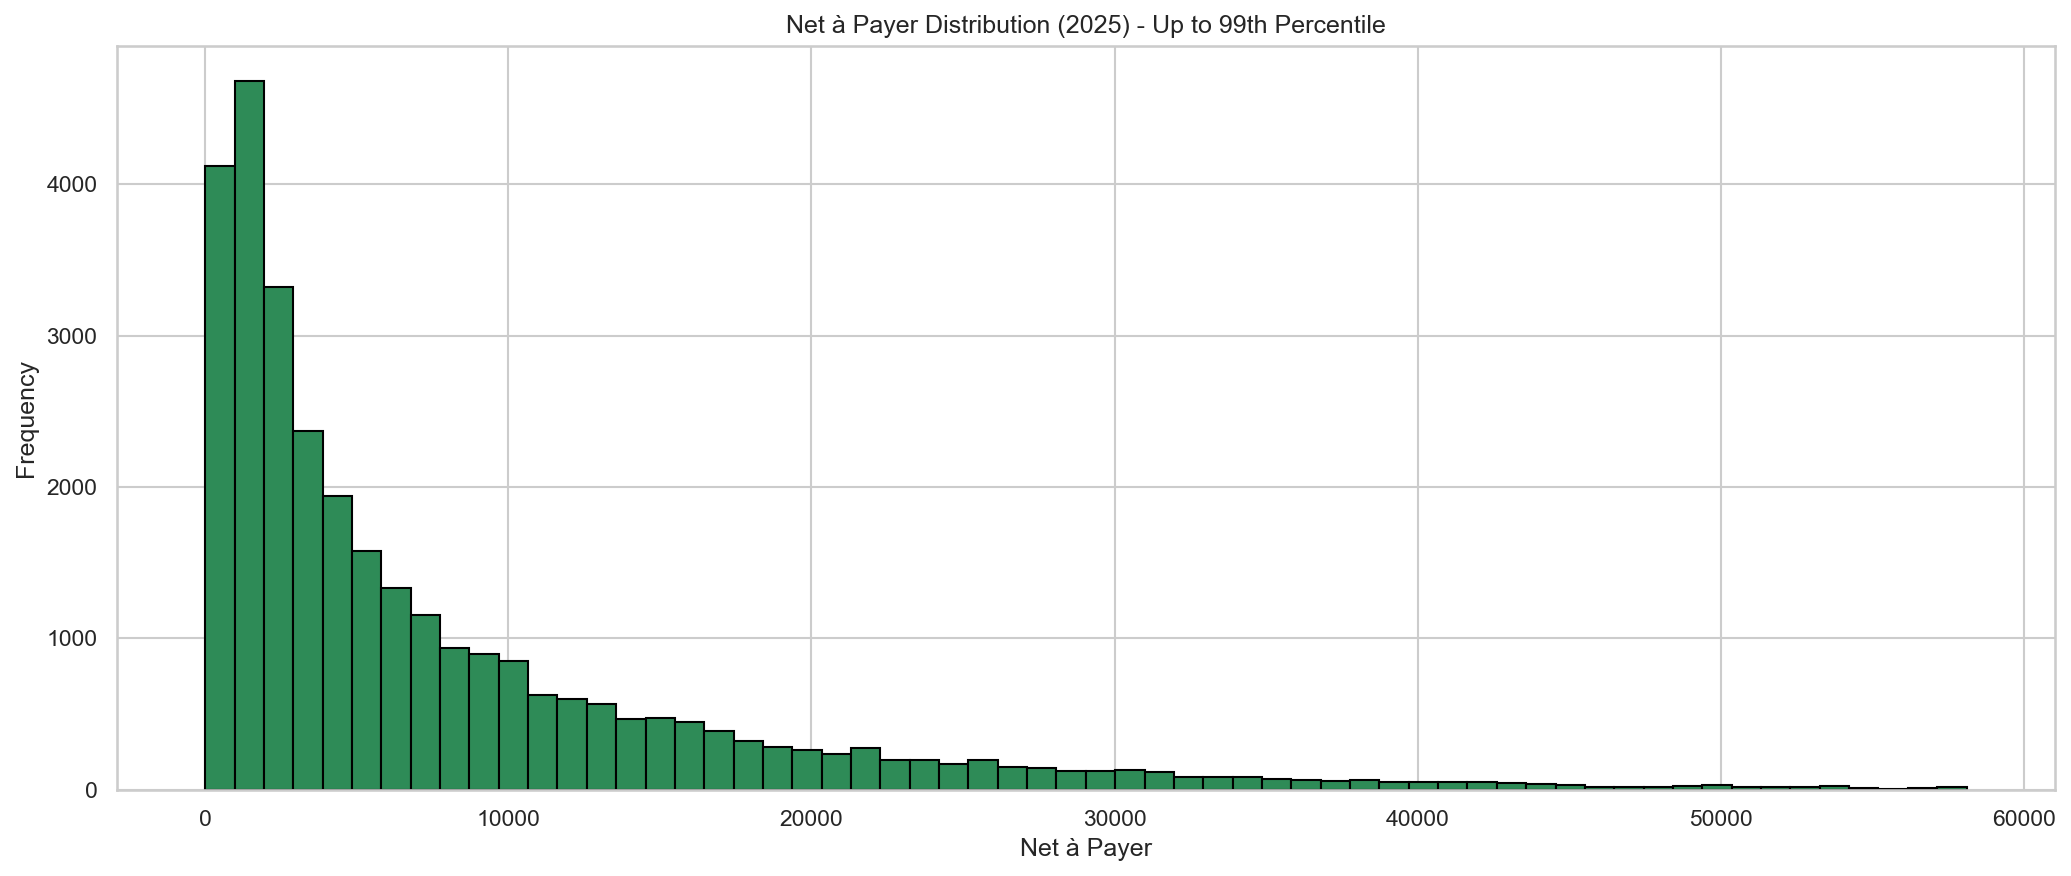

In [11]:
for year in [2024, 2025]:
      sales = df.loc[df['Année'] == year, 'Net à Payer'].dropna()
      p99 = sales.quantile(0.99)

      fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
      ax.hist(sales[sales <= p99], bins=60, color='seagreen', edgecolor='black')
      ax.set_title(f'Net à Payer Distribution ({year}) - Up to 99th Percentile')
      ax.set_xlabel('Net à Payer')
      ax.set_ylabel('Frequency')
      plt.tight_layout()
      plt.show()


## Client spending distribution


### normal


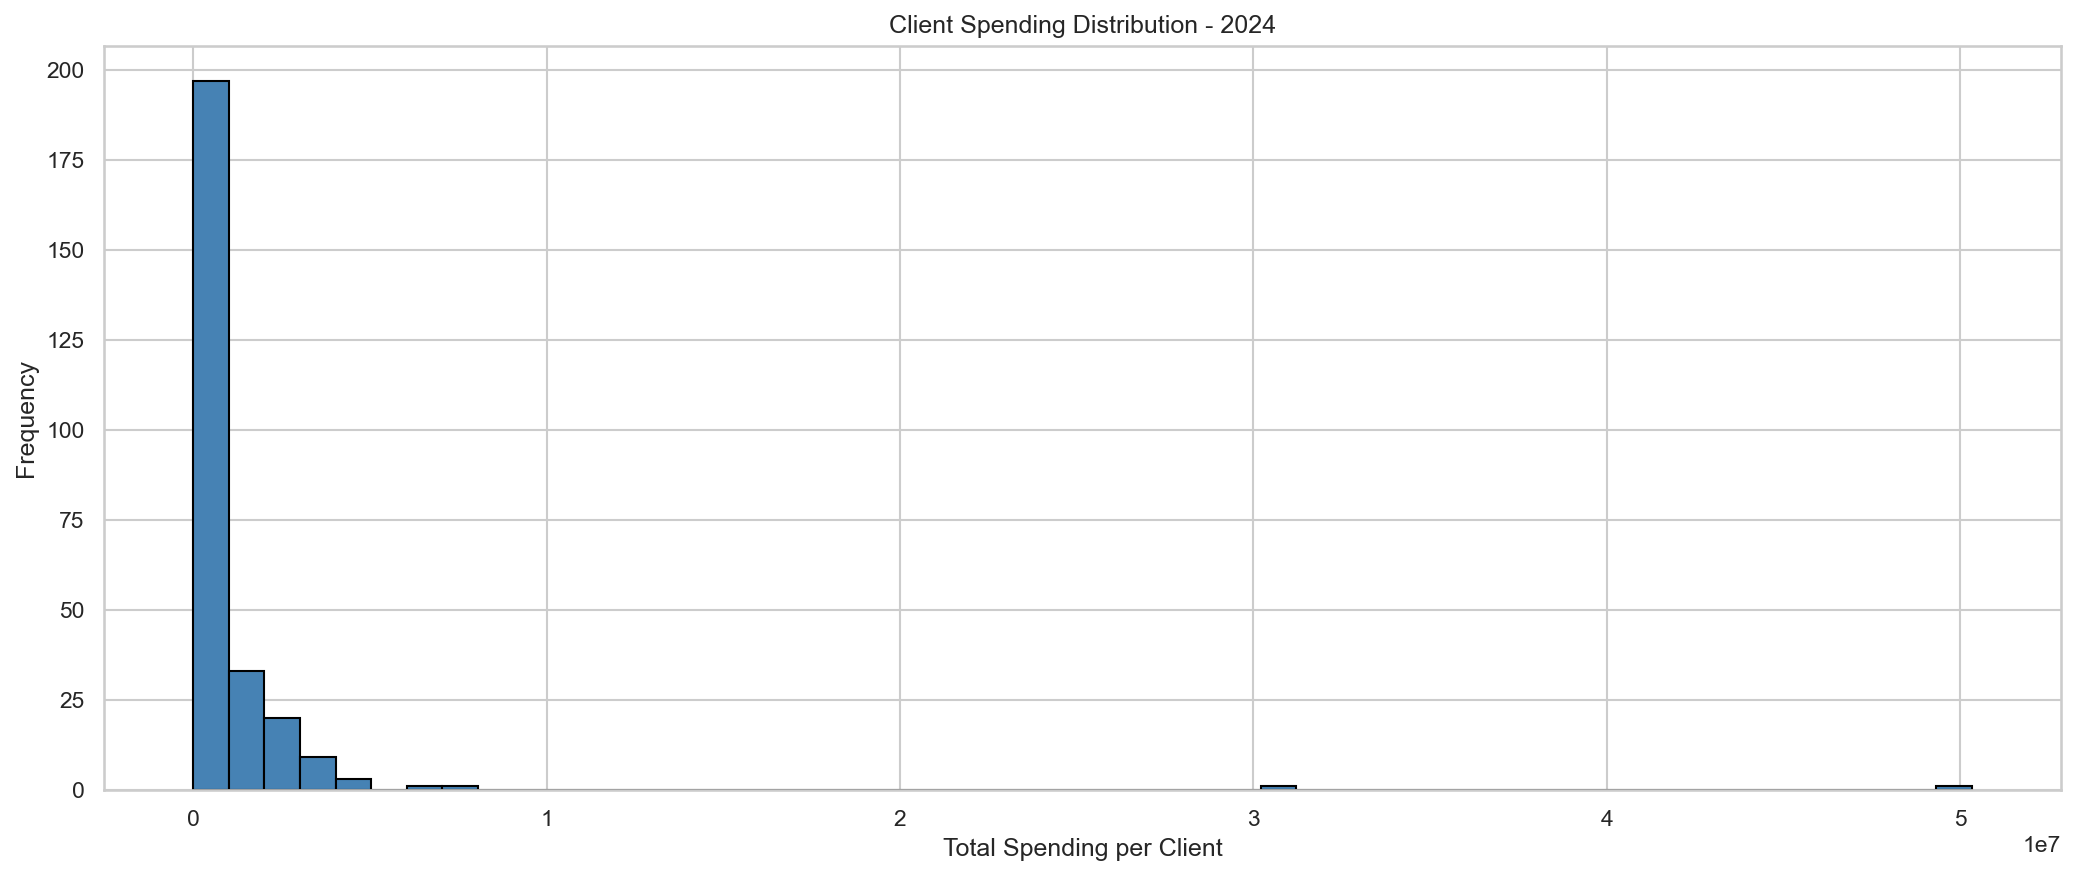

In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Année'] = df['Date'].dt.year

# 2024
client_spend_2024 = df[df['Année'] == 2024].groupby('Code Client')['Net à Payer'].sum()
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(client_spend_2024, bins=50, color='steelblue', edgecolor='black')
ax.set_title('Client Spending Distribution - 2024')
ax.set_xlabel('Total Spending per Client')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


**Interpretation**

The `Solde global` distribution shows that most records are associated with positive balances, while only a small minority are negative. This indicates that most customer accounts remain within a positive balance structure, although some accounts show exceptional balance behavior that may deserve closer managerial attention.


###  Log (Y scale)


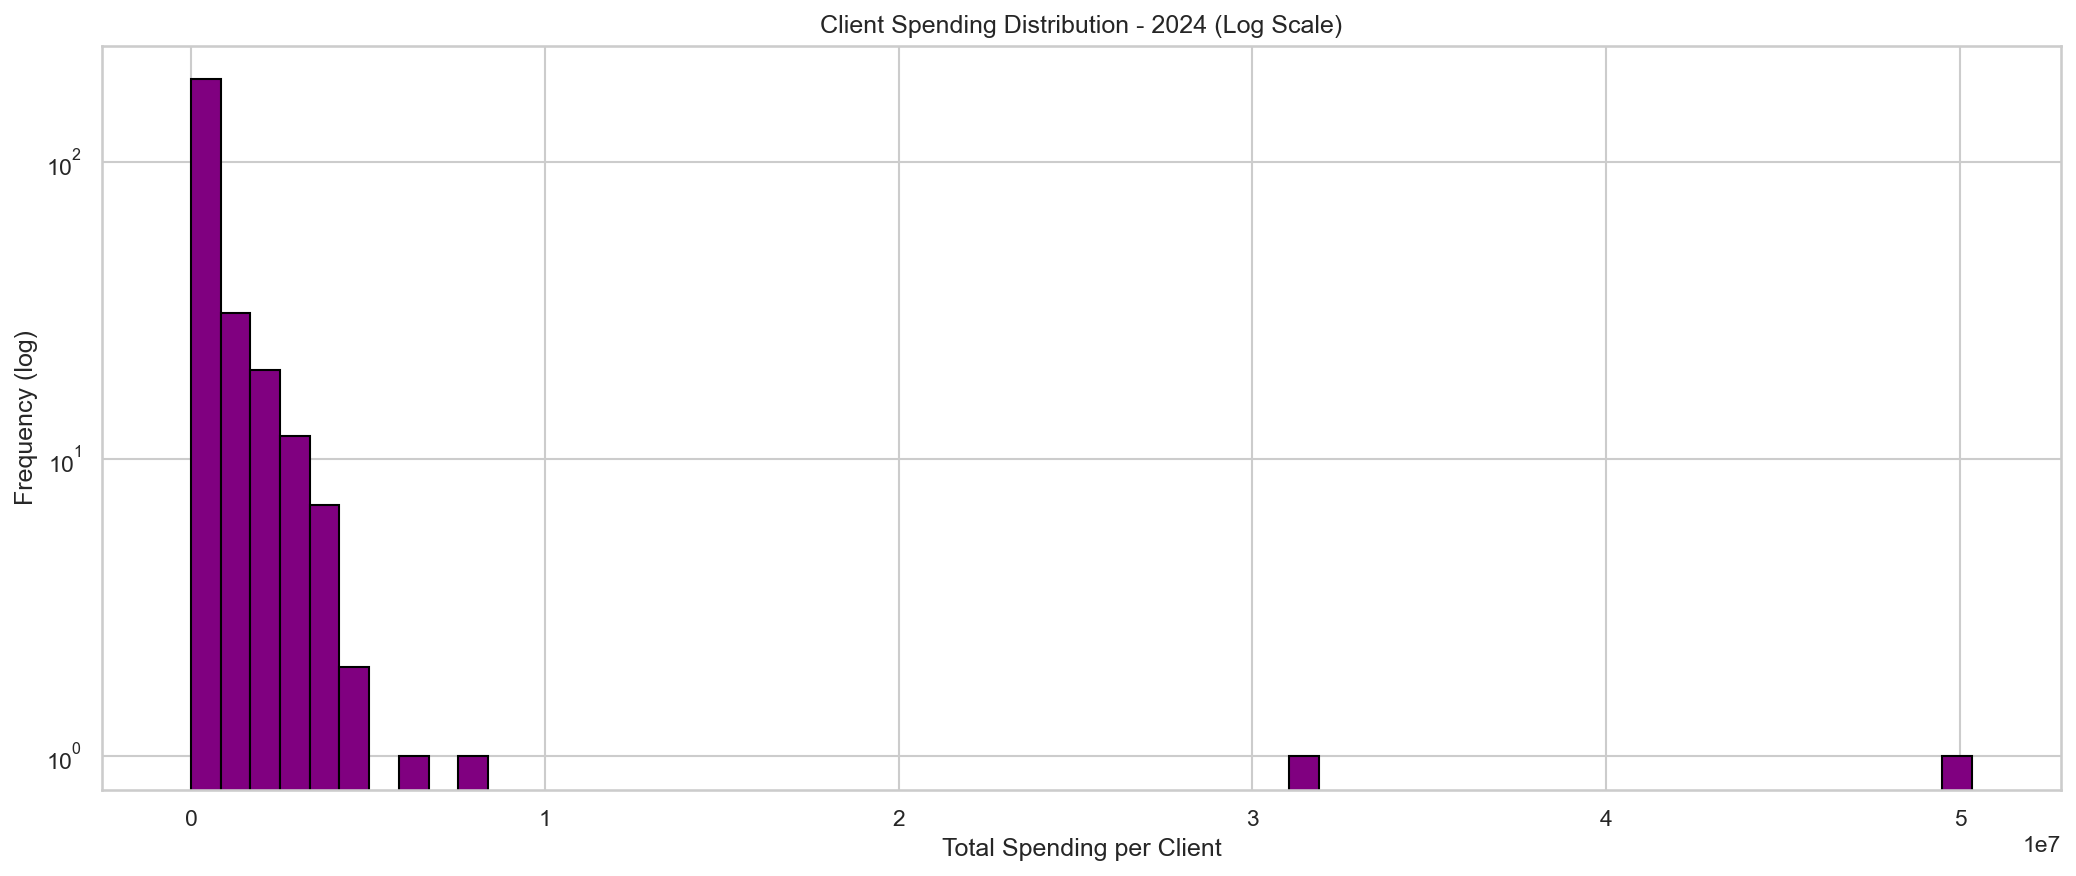

In [13]:
# 2024
client_spend_2024 = df[df['Année'] == 2024].groupby('Code Client')['Net à Payer'].sum()
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(client_spend_2024, bins=60, color='purple', edgecolor='black', log=True)
ax.set_title('Client Spending Distribution - 2024 (Log Scale)')
ax.set_xlabel('Total Spending per Client')
ax.set_ylabel('Frequency (log)')
plt.tight_layout()
plt.show()


### zom 99%


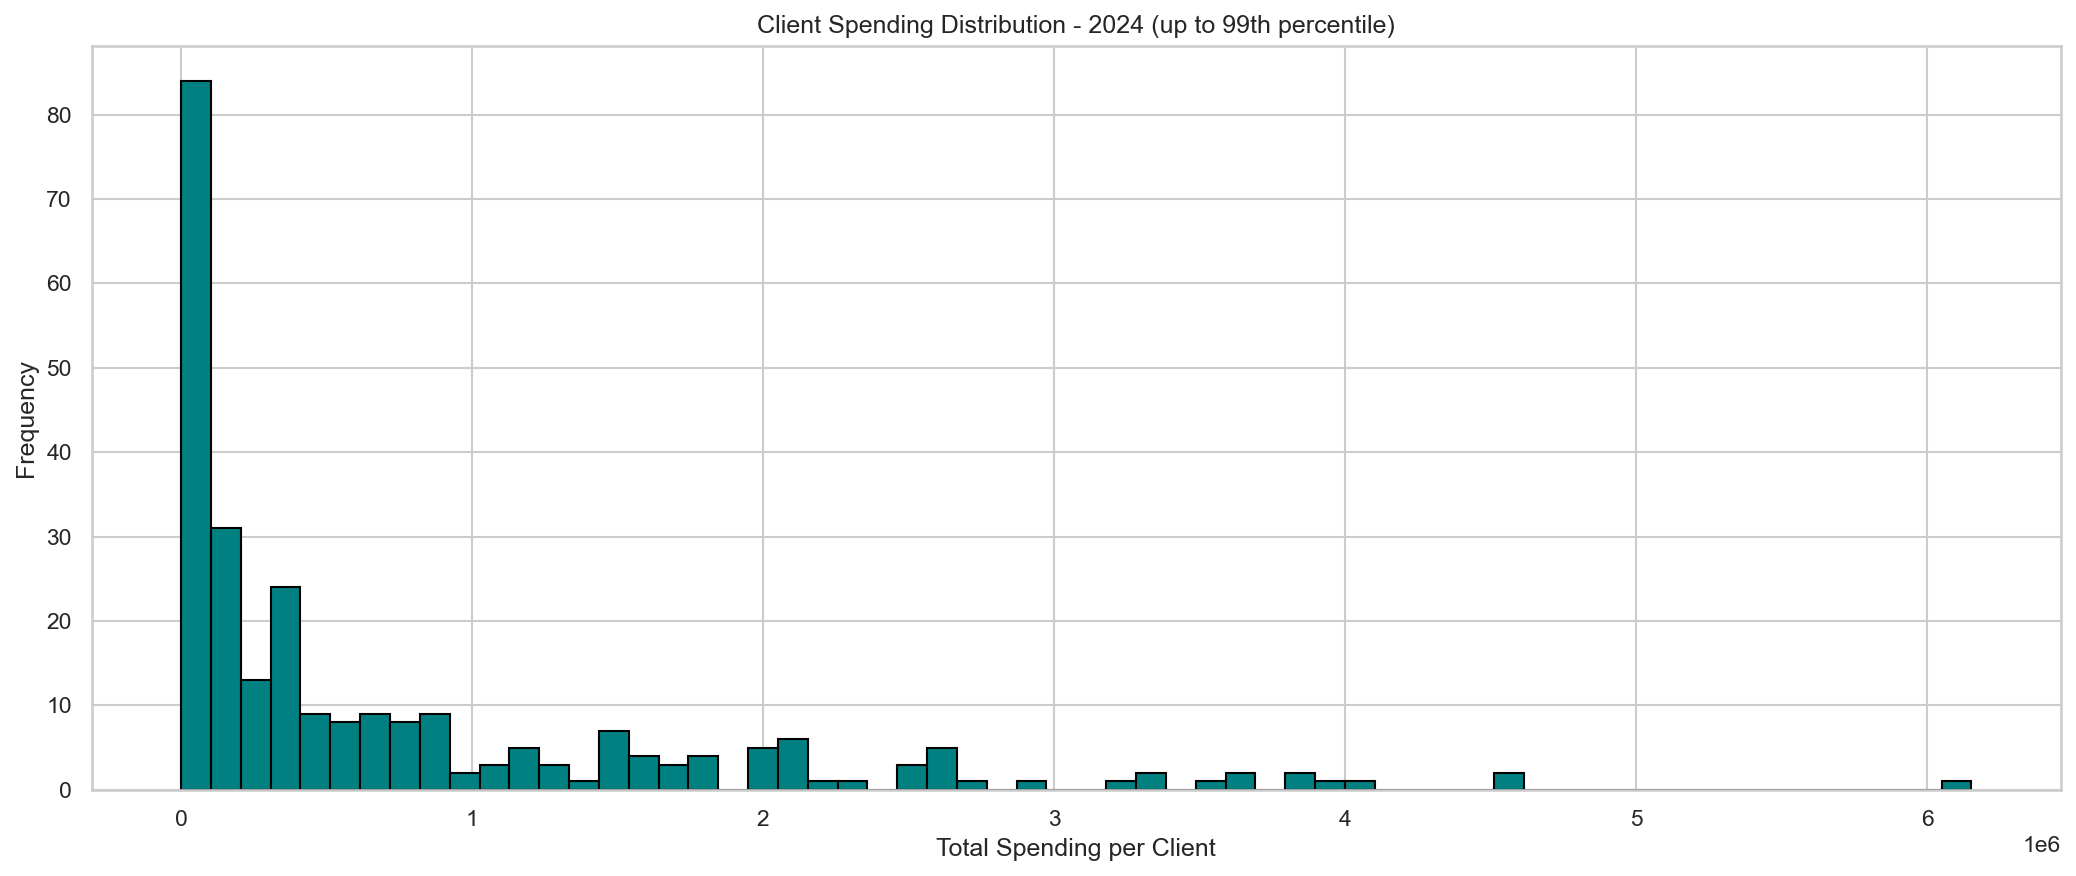

In [14]:
# 2024
p99_2024 = client_spend_2024.quantile(0.99)
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(client_spend_2024[client_spend_2024 <= p99_2024], bins=60, color='teal', edgecolor='black')
ax.set_title('Client Spending Distribution - 2024 (up to 99th percentile)')
ax.set_xlabel('Total Spending per Client')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


### solde global distribution


In [15]:
solde = df['Solde global'].dropna()

positive = (solde > 0).sum()
zero = (solde == 0).sum()
negative = (solde < 0).sum()
total = len(solde)

solde_status = pd.DataFrame({
    'Status': ['Positive', 'Zero', 'Negative'],
    'Count': [positive, zero, negative],
    'Percent': [positive / total * 100, zero / total * 100, negative / total * 100]
})
display(solde_status)


,Status,Count,Percent
0,Positive,54859,89.14
1,Zero,4884,7.94
2,Negative,1802,2.93


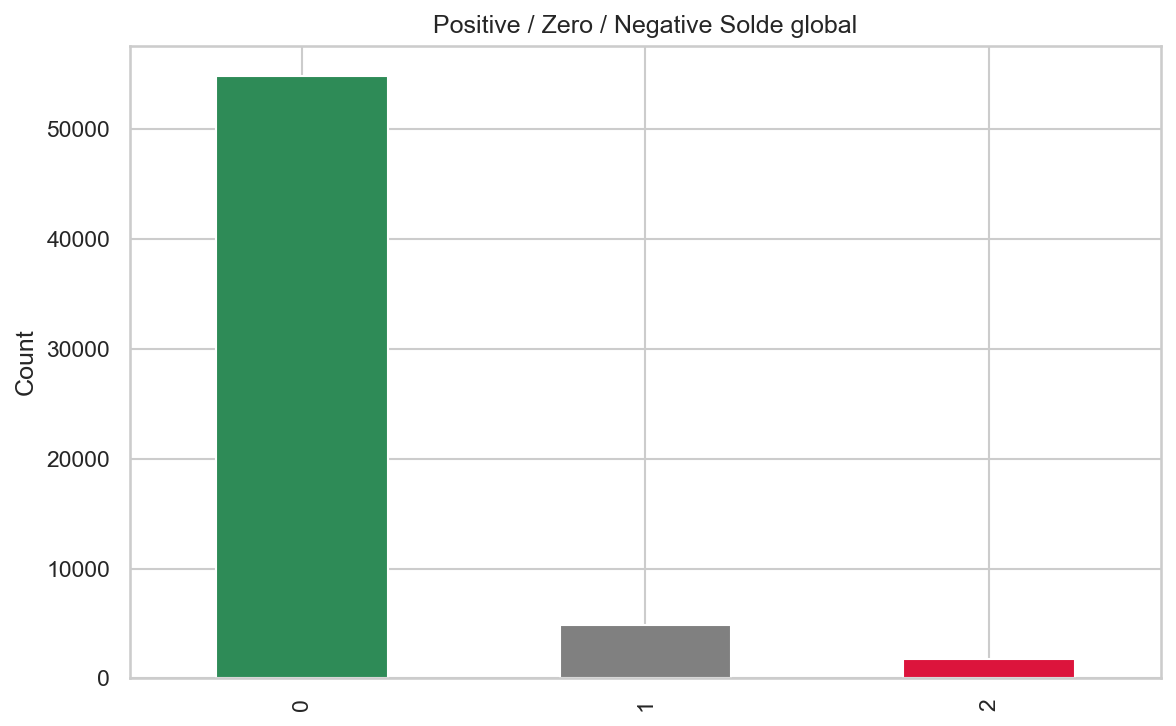

In [16]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
solde_status['Count'].plot(kind='bar', color=['seagreen', 'gray', 'crimson'], ax=ax)
ax.set_title('Positive / Zero / Negative Solde global')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


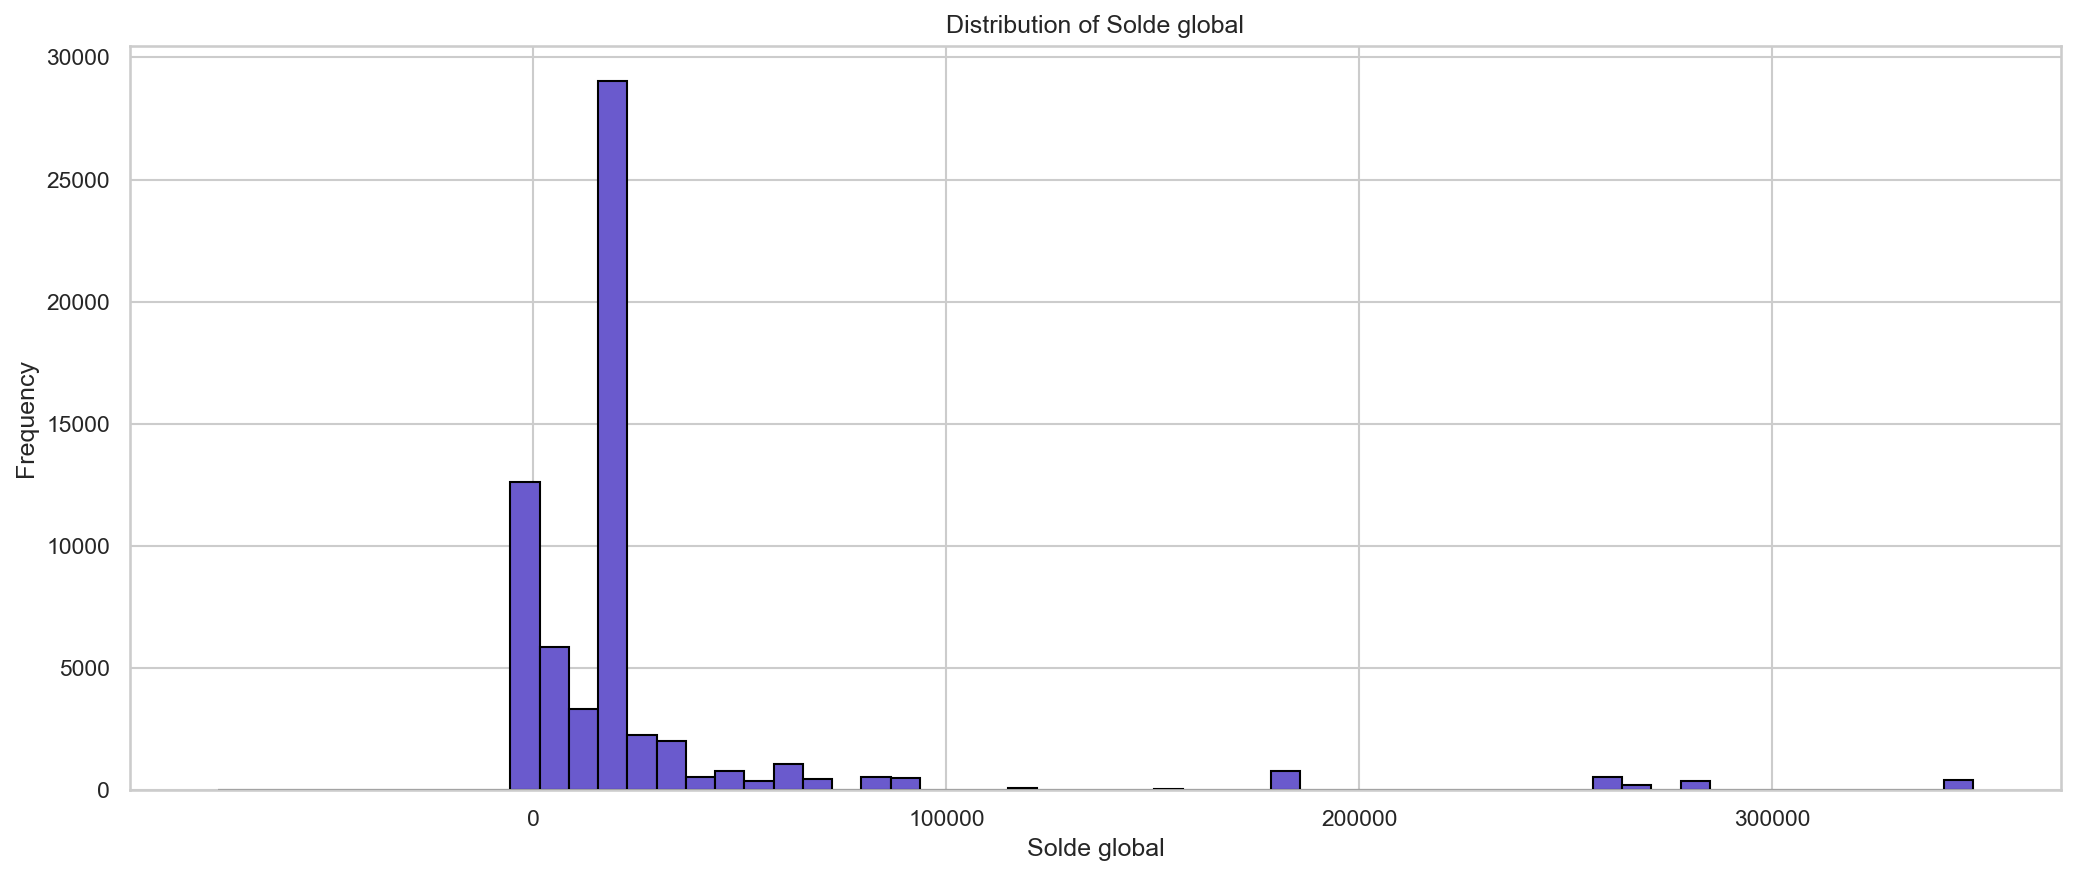

In [17]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(solde, bins=60, color='slateblue', edgecolor='black')
ax.set_title('Distribution of Solde global')
ax.set_xlabel('Solde global')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


### payement status


In [18]:
paid = (df['Reste à payer'] == 0).sum()
underpaid = (df['Reste à payer'] > 0).sum()
overpaid = (df['Reste à payer'] < 0).sum()
total = len(df)
print('Paid (reste=0):', paid)
print('Underpaid (reste>0):', underpaid)
print('Overpaid (reste<0):', overpaid)


Paid (reste=0): 35115
Underpaid (reste>0): 12722
Overpaid (reste<0): 13708


**Interpretation**

The payment-status breakdown shows three distinct behaviors: fully paid invoices, underpaid invoices, and overpaid situations. The large number of overpaid or negative `Reste ? payer` cases suggests that payment reconciliation is not uniform across clients and may reflect account-level settlement practices rather than invoice-level balance closure.


## 5 - Outlier analysis


### outlier detection (iqr)


In [19]:
q1 = df['Net à Payer'].quantile(0.25)
q3 = df['Net à Payer'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df['Outlier_Net'] = (df['Net à Payer'] < lower) | (df['Net à Payer'] > upper)
print(df['Outlier_Net'].value_counts())
print("IQR:", iqr, "Lower:", lower, "Upper:", upper)


Outlier_Net
False    56524
True      5021
Name: count, dtype: int64
IQR: 9000.1 Lower: -11770.150000000001 Upper: 24230.25


**Interpretation**

The IQR method identifies 5,248 outliers in `Net ? Payer`, representing about 8.22% of the dataset. These observations should not be removed automatically because they are economically meaningful and likely correspond to major transactions or important clients. For a business study, these outliers are often part of the main story rather than noise.


### Top clients with total outliers (Net à Payer)


In [20]:
outlier_clients = (
    df[df['Outlier_Net']]
    .groupby('Code Client')['Net à Payer']
    .agg(outlier_count='count', outlier_total='sum')
    .sort_values('outlier_total', ascending=False)
)
display(outlier_clients.head(10))


,outlier_count,outlier_total
Code Client,,
BO000021,213,"38,047,810.80"
AA000002,508,"19,924,398.39"
NO000002,325,"16,674,942.42"
AH000004,230,"8,088,051.11"
AZ000002,132,"6,991,447.73"
BE000004,149,"6,240,968.27"
AD000001,141,"4,424,568.31"
CH000002,107,"4,095,411.72"
HA000013,88,"3,629,292.51"


In [21]:
client_name = (
    df.groupby('Code Client')['Raison Sociale']
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
)

top10_outlier = outlier_clients.head(10).reset_index()
top10_outlier['Raison Sociale'] = top10_outlier['Code Client'].map(client_name)
display(top10_outlier)


,Code Client,outlier_count,outlier_total,Raison Sociale
0,BO000021,213,"38,047,810.80",BOROUMI
1,AA000002,508,"19,924,398.39",AAAAAA
2,NO000002,325,"16,674,942.42",NOURDINE DJEBAR
3,AH000004,230,"8,088,051.11",/AHMED CHOUIH
4,AZ000002,132,"6,991,447.73",AZZEDDINE LA SOURSSE
5,BE000004,149,"6,240,968.27",BEN AHMED MOHAMED
6,AD000001,141,"4,424,568.31",ADDA IBRAHIM
7,CH000002,107,"4,095,411.72",CHELALI RABEH ZEDRI
8,HA000013,88,"3,629,292.51",HALIM
9,BO000019,106,"3,621,210.82",BOUAMRA LABEN


**Interpretation**

The top outlier clients account for very large cumulative amounts. This confirms that extreme values are linked to specific customers rather than being randomly distributed. In practical terms, the company appears to rely on a limited set of high-value accounts that generate unusually large invoice volumes.


### Outliers vs revenu total (client)


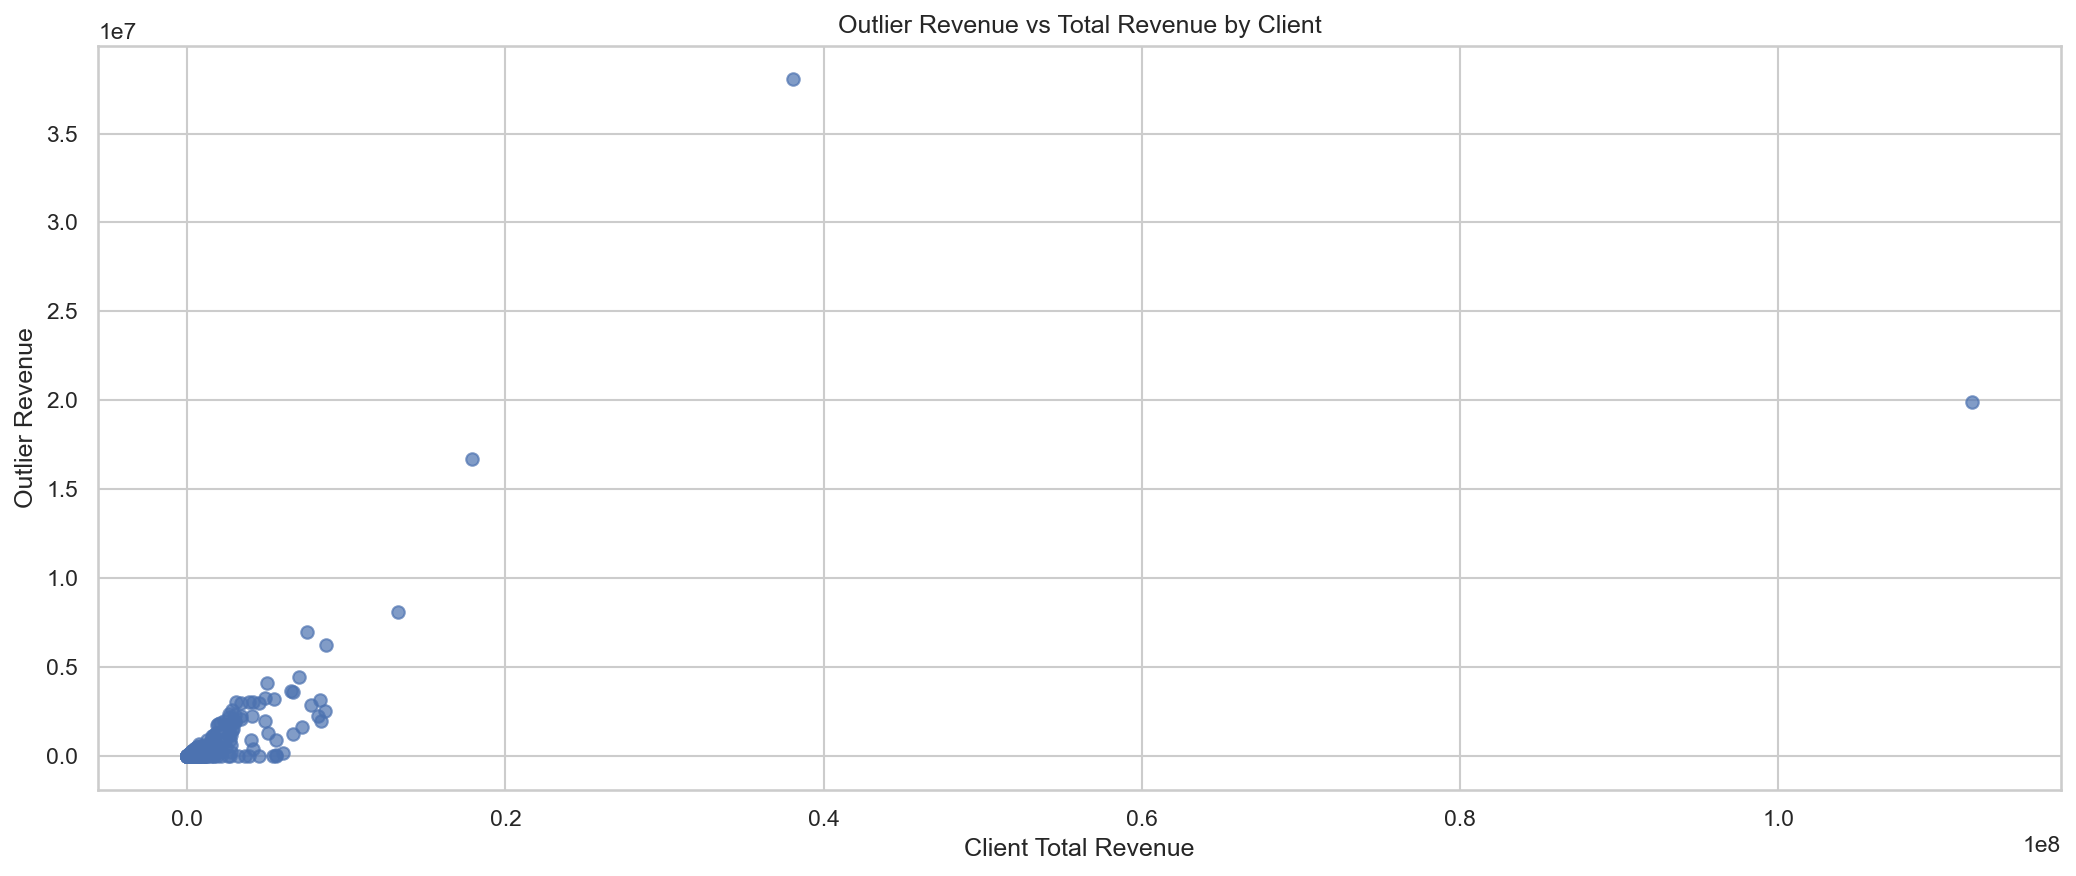

In [22]:
client_total = df.groupby('Code Client')['Net à Payer'].sum()
outlier_total = outlier_clients['outlier_total']

scatter_df = pd.DataFrame({
    'client_total': client_total,
    'outlier_total': outlier_total
}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.scatter(scatter_df['client_total'], scatter_df['outlier_total'], alpha=0.7)
ax.set_title('Outlier Revenue vs Total Revenue by Client')
ax.set_xlabel('Client Total Revenue')
ax.set_ylabel('Outlier Revenue')
plt.tight_layout()
plt.show()


### Evolution mensuelle des outliers


In [23]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
outlier_time = (
    df[df['Outlier_Net']]
    .groupby(df['Date'].dt.to_period('M'))['Net à Payer']
    .sum()
)
outlier_time.index = outlier_time.index.to_timestamp()
display(outlier_time.head())


Date
2024-01-01   10,617,520.66
2024-02-01   12,188,907.97
2024-03-01   11,099,755.33
2024-04-01   13,333,515.32
2024-05-01   11,311,580.36
Freq: MS, Name: Net à Payer, dtype: float64

**Interpretation**

The monthly evolution of outlier revenue shows that large transactions occur throughout the year rather than being isolated to a single short period. This suggests that high-value business activity is a recurring feature of the company?s operations, not just an occasional anomaly.


### Boxplot des outliers


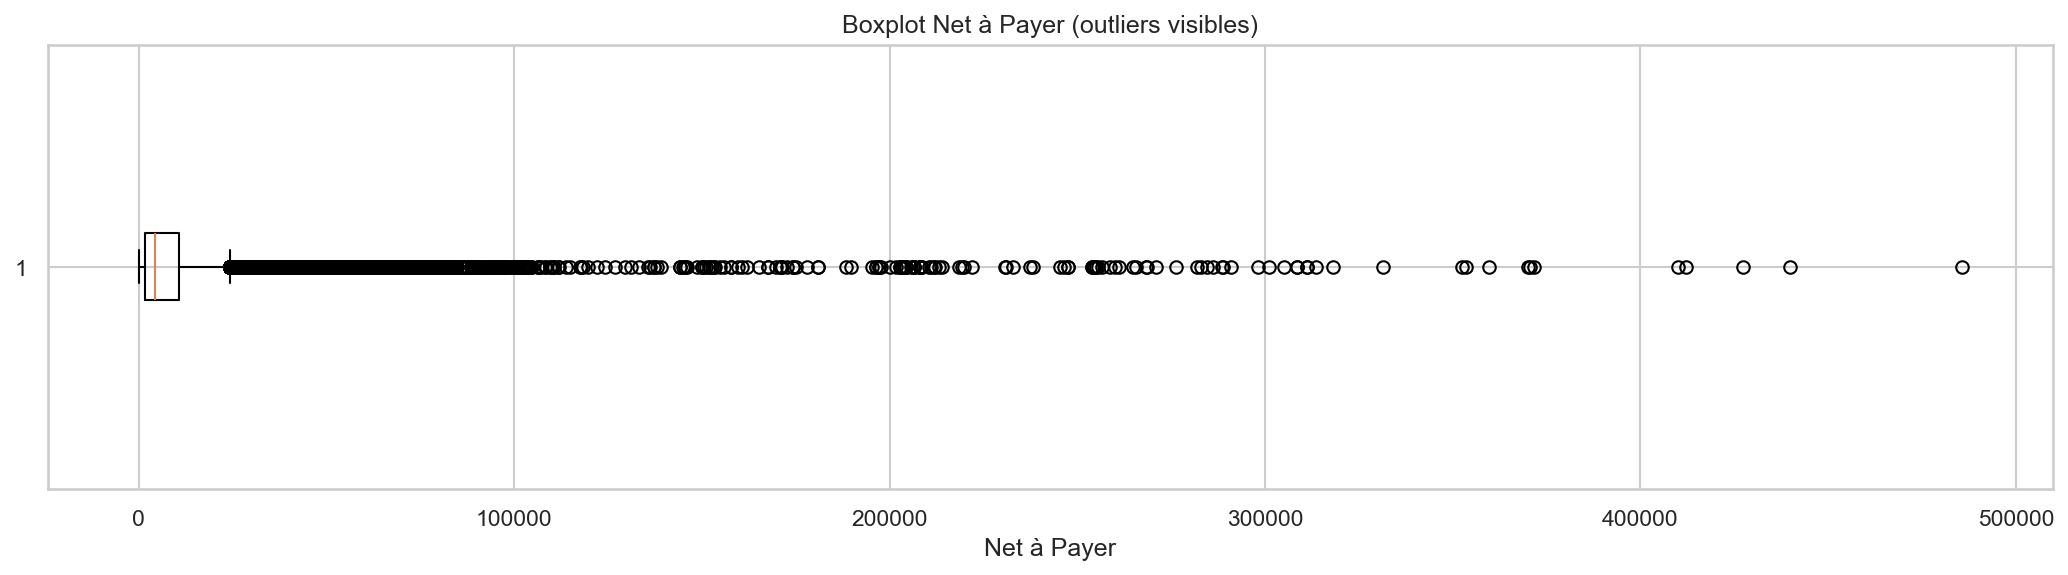

In [24]:
fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.boxplot(df['Net à Payer'].dropna(), vert=False)
ax.set_title('Boxplot Net à Payer (outliers visibles)')
ax.set_xlabel('Net à Payer')
plt.tight_layout()
plt.show()


### Pareto Analysis (outliers)


In [25]:
# Sort clients by outlier_total
sorted_outliers = outlier_clients.sort_values(by='outlier_total', ascending=False)

# Compute cumulative percentage
sorted_outliers['cum_share'] = sorted_outliers['outlier_total'].cumsum() / sorted_outliers['outlier_total'].sum()
display(sorted_outliers.head(10))


,outlier_count,outlier_total,cum_share
Code Client,,,
BO000021,213,"38,047,810.80",0.17
AA000002,508,"19,924,398.39",0.26
NO000002,325,"16,674,942.42",0.33
AH000004,230,"8,088,051.11",0.36
AZ000002,132,"6,991,447.73",0.40
BE000004,149,"6,240,968.27",0.42
AD000001,141,"4,424,568.31",0.44
CH000002,107,"4,095,411.72",0.46
HA000013,88,"3,629,292.51",0.48


In [26]:
# Clients contributing to 80%
top_80 = sorted_outliers[sorted_outliers['cum_share'] <= 0.8]

print("Number of clients in top 80%:", len(top_80))
print(top_80.reset_index()[['Code Client', 'outlier_total', 'cum_share']].head(20))


Number of clients in top 80%: 39
   Code Client  outlier_total  cum_share
0     BO000021  38,047,810.80       0.17
1     AA000002  19,924,398.39       0.26
2     NO000002  16,674,942.42       0.33
3     AH000004   8,088,051.11       0.36
4     AZ000002   6,991,447.73       0.40
5     BE000004   6,240,968.27       0.42
6     AD000001   4,424,568.31       0.44
7     CH000002   4,095,411.72       0.46
8     HA000013   3,629,292.51       0.48
9     BO000019   3,621,210.82       0.49
10    BO000026   3,276,245.60       0.51
11    SUP00001   3,196,637.65       0.52
12    MI000004   3,176,504.92       0.53
13    ME000008   3,022,860.85       0.55
14    CH000001   3,015,486.47       0.56
15    NA000007   3,011,175.68       0.57
16    MO000015   2,987,468.08       0.59
17    FE000002   2,980,858.59       0.60
18    GU000003   2,851,960.81       0.61
19    GU000004   2,615,060.70       0.63


**Interpretation**

Only 39 clients are needed to explain 80% of outlier revenue. This is a strong Pareto-type concentration pattern, indicating that a small group of customers contributes disproportionately to the highest-value transactions. From a managerial perspective, these clients should be considered strategically important.


## 6 - Bivariate Analysis


### 1 Sales vs clients (total revenue per client vs number of clients)


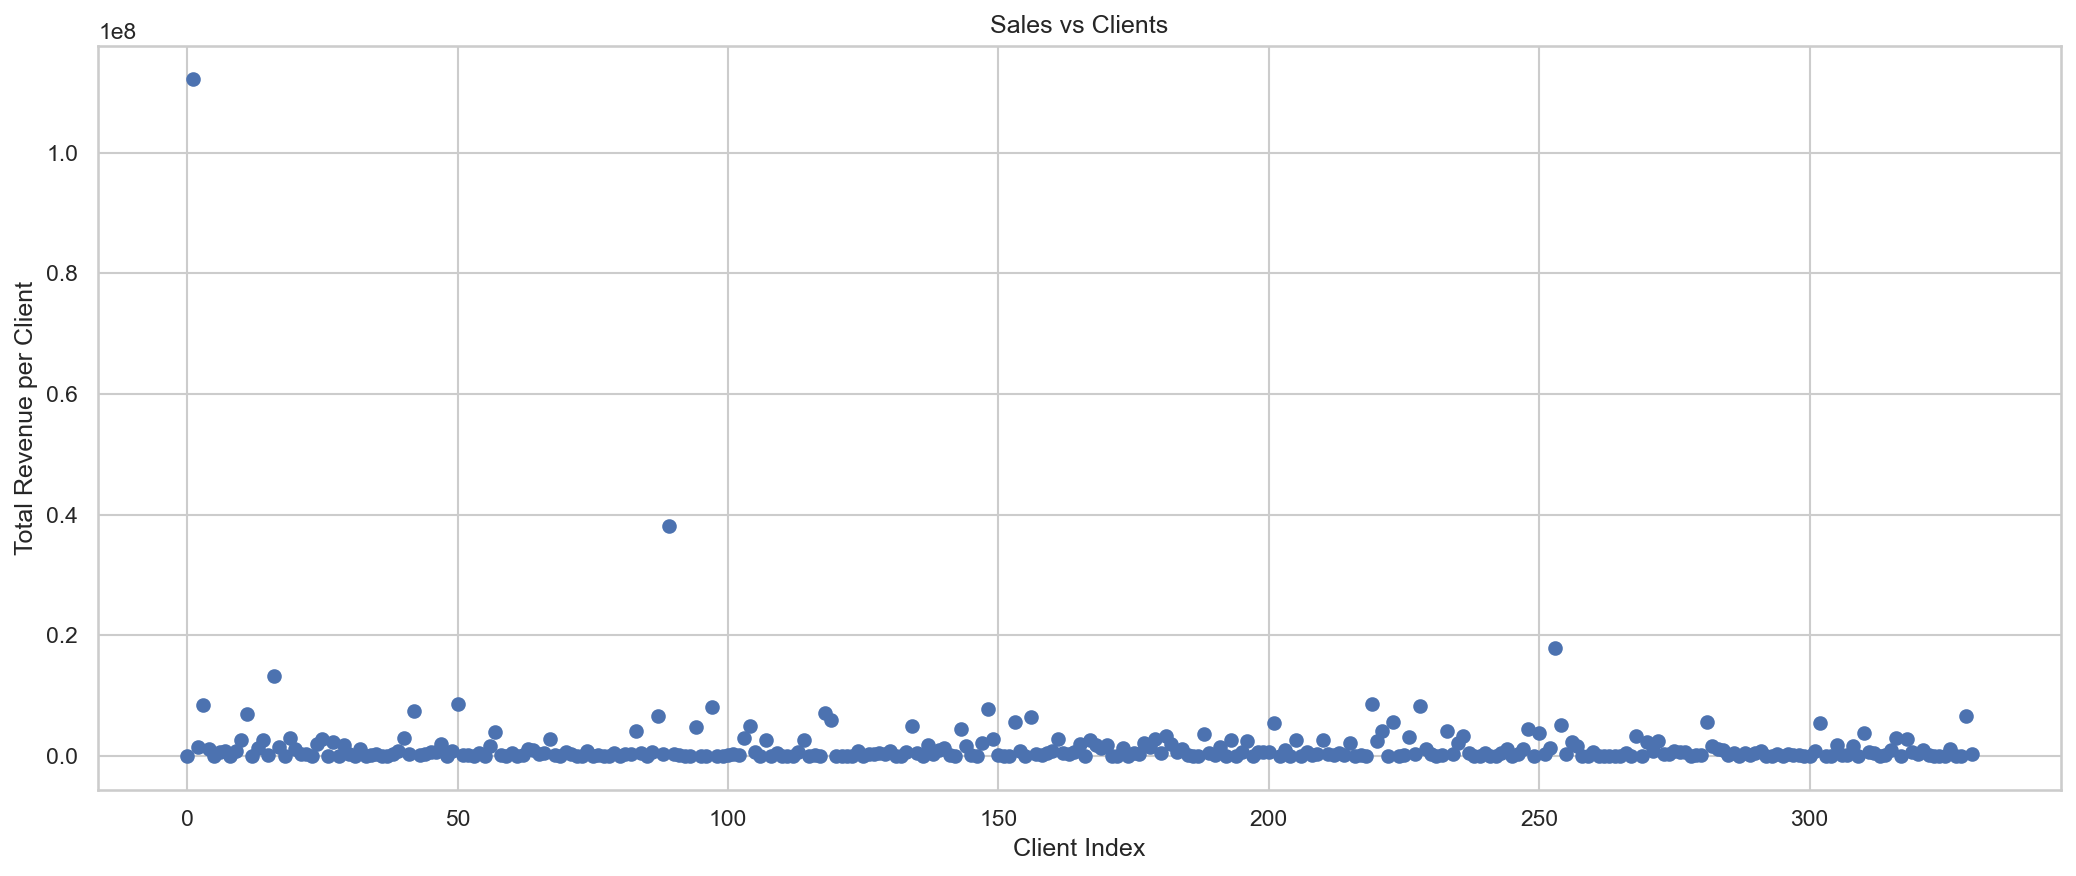

In [27]:
client_revenue = df.groupby('Code Client')['Net à Payer'].sum()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.scatter(range(len(client_revenue)), client_revenue.values)
ax.set_title('Sales vs Clients')
ax.set_xlabel('Client Index')
ax.set_ylabel('Total Revenue per Client')
plt.tight_layout()
plt.show()


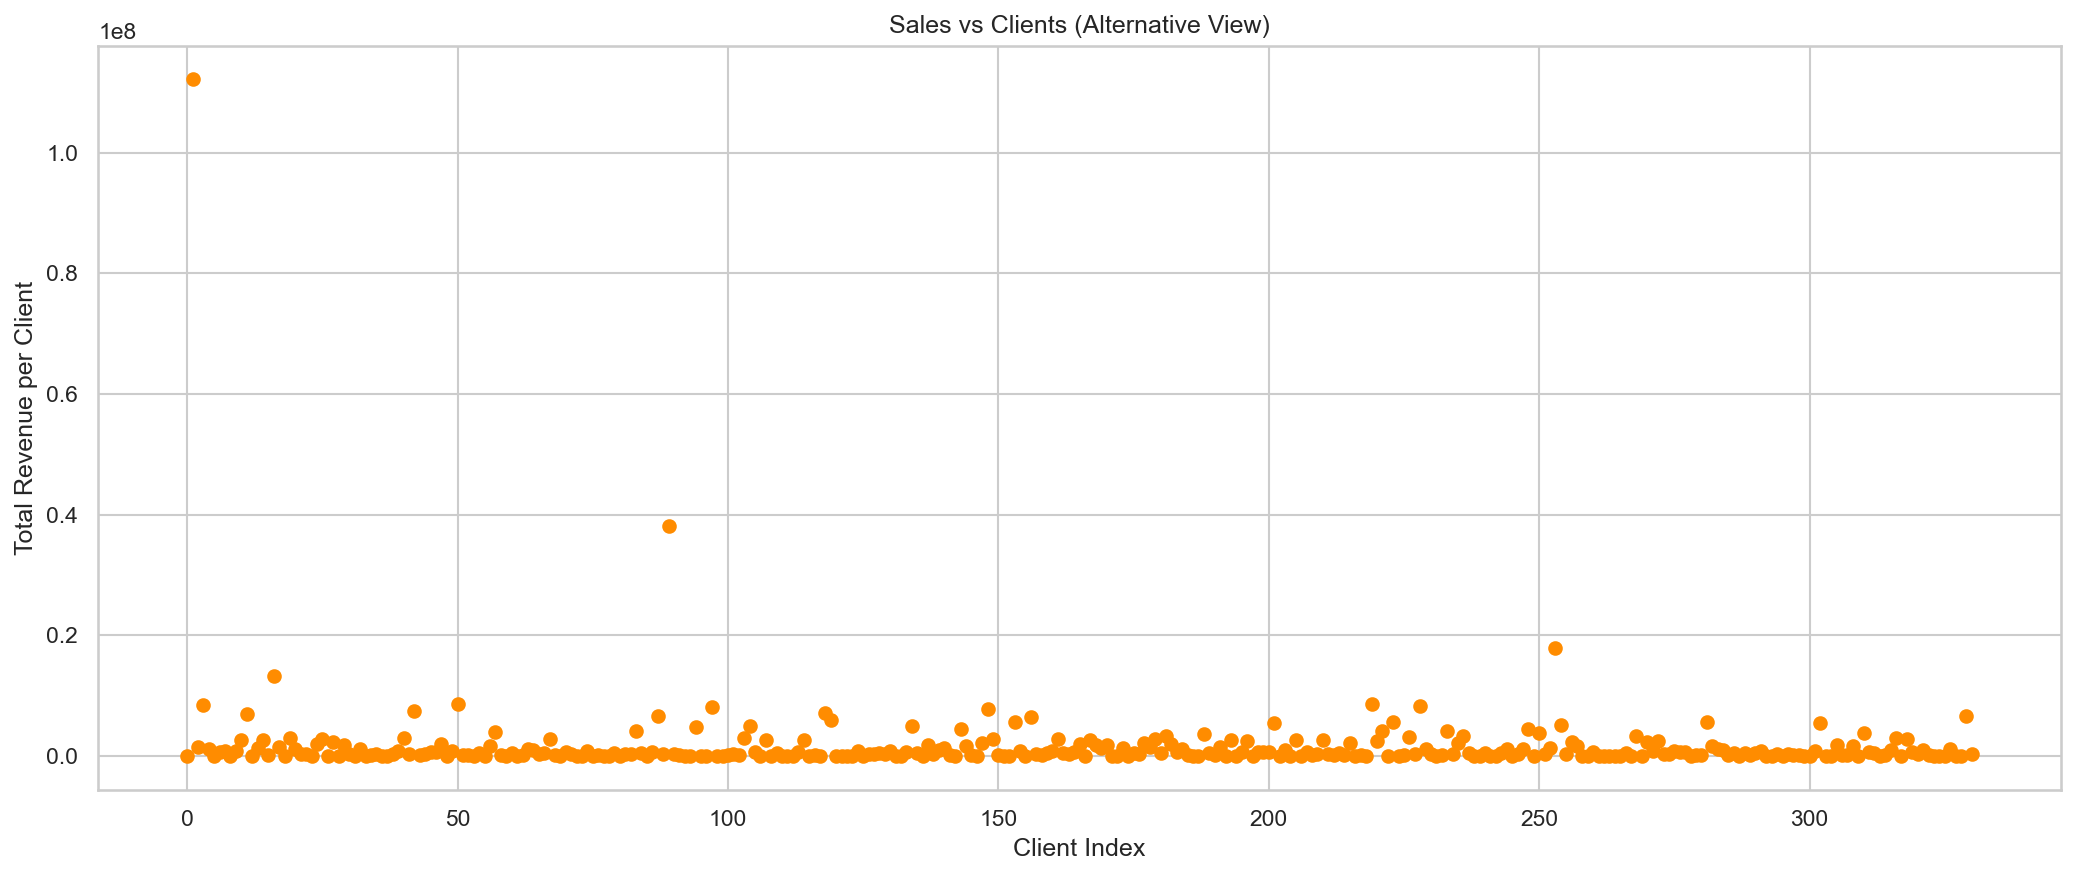

In [28]:
client_revenue = df.groupby('Code Client')['Net à Payer'].sum()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.scatter(range(len(client_revenue)), client_revenue.values, color='darkorange')
ax.set_title('Sales vs Clients (Alternative View)')
ax.set_xlabel('Client Index')
ax.set_ylabel('Total Revenue per Client')
plt.tight_layout()
plt.show()


### Number of purchases vs revenue


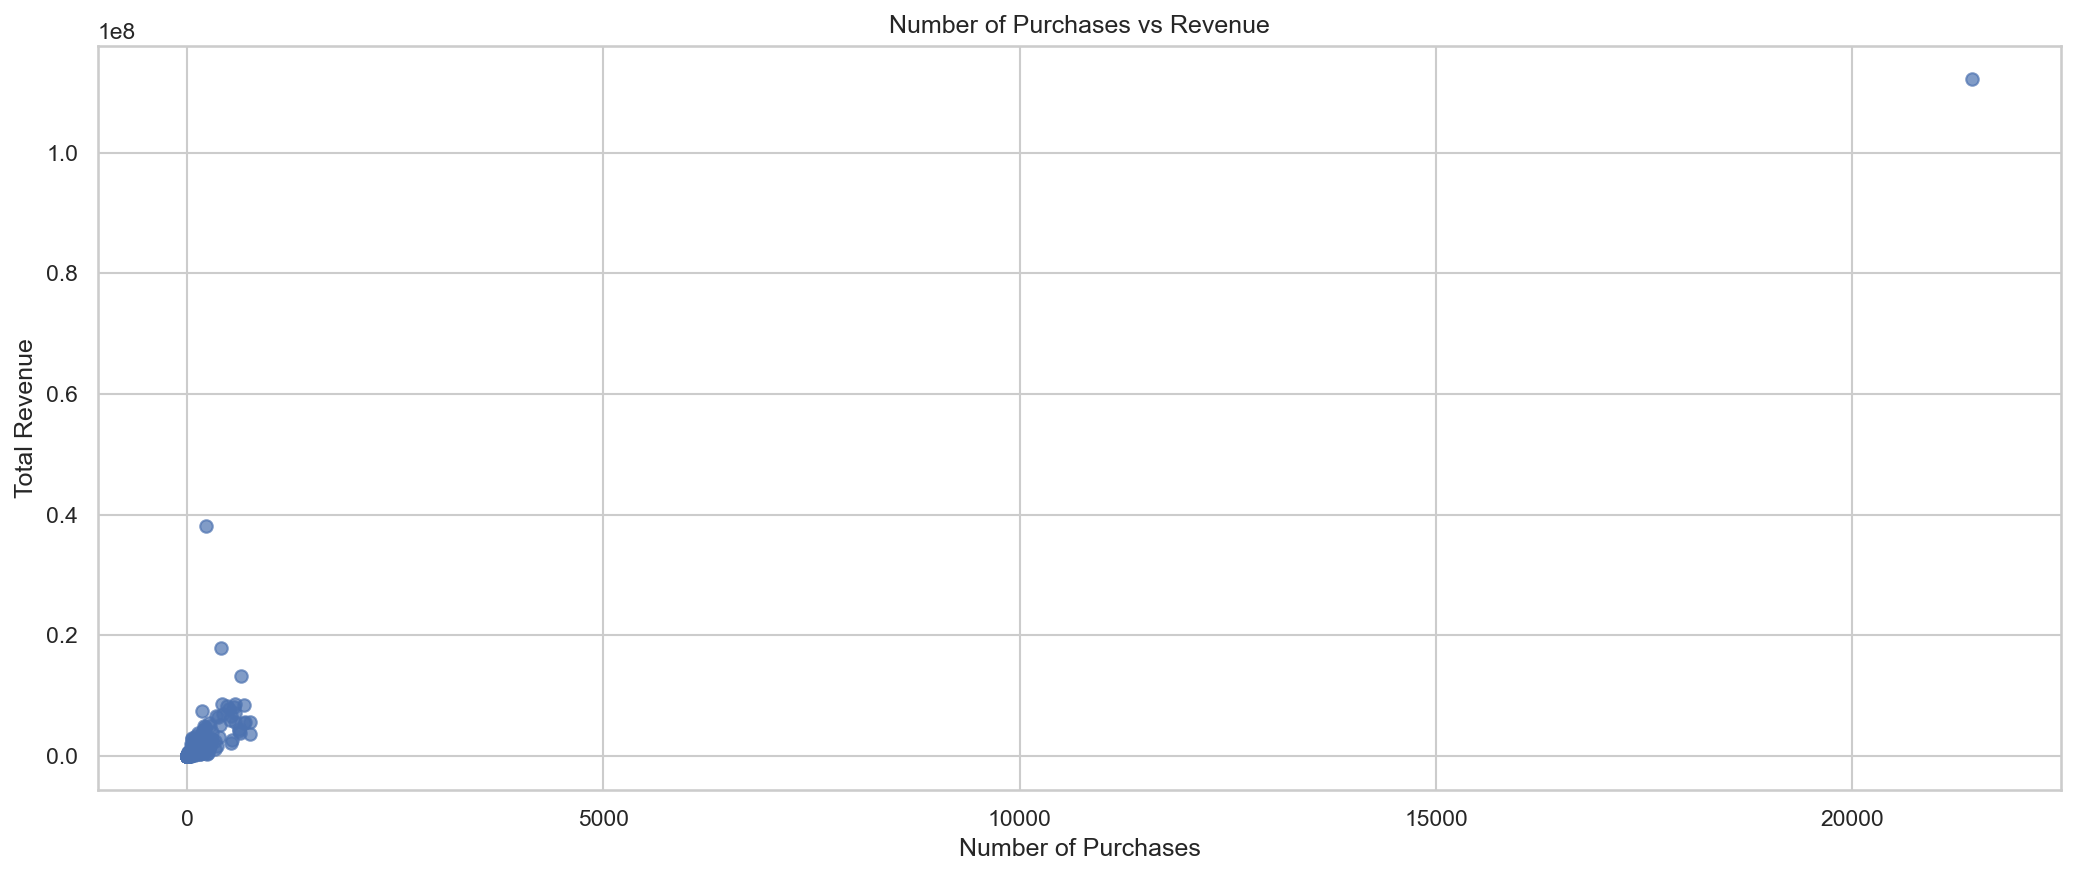

In [29]:
client_stats = df.groupby('Code Client').agg(
nb_achats=('Numéro de facture', 'nunique'),
total_revenue=('Net à Payer', 'sum')
)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.scatter(client_stats['nb_achats'], client_stats['total_revenue'], alpha=0.7)
ax.set_title('Number of Purchases vs Revenue')
ax.set_xlabel('Number of Purchases')
ax.set_ylabel('Total Revenue')
plt.tight_layout()
plt.show()


### Solde global by client


In [30]:
client_solde = (
    df.dropna(subset=['Solde global'])
    .groupby('Code Client', as_index=False)
    .agg({
        'Raison Sociale': 'first',
        'Solde global': 'sum'
    })
    .sort_values('Solde global', ascending=False)
)
display(client_solde.head(10))


,Code Client,Raison Sociale,Solde global
1,AA000002,AAAAAA,"434,617,554.00"
253,NO000002,NOURDINE DJEBAR,"142,250,974.80"
205,MA000005,MAAIZI TAIBE,"140,871,147.23"
153,HA000009,HAIRECH DJAMEL,"138,565,580.35"
156,HA000013,HALIM,"105,990,919.32"
19,AL000002,ALILI AHMED,"49,987,468.52"
228,MI000004,MILOUDI MAHFOUD,"44,320,903.38"
329,ZO000001,ZOUBIR MOHAMED LARBI,"43,060,760.86"
118,DJ000007,DJILALI HAWCH NOIR,"34,775,419.56"
223,ME130001,MELLAS RACHID,"31,114,266.81"


### Correlation matrix (numerical)


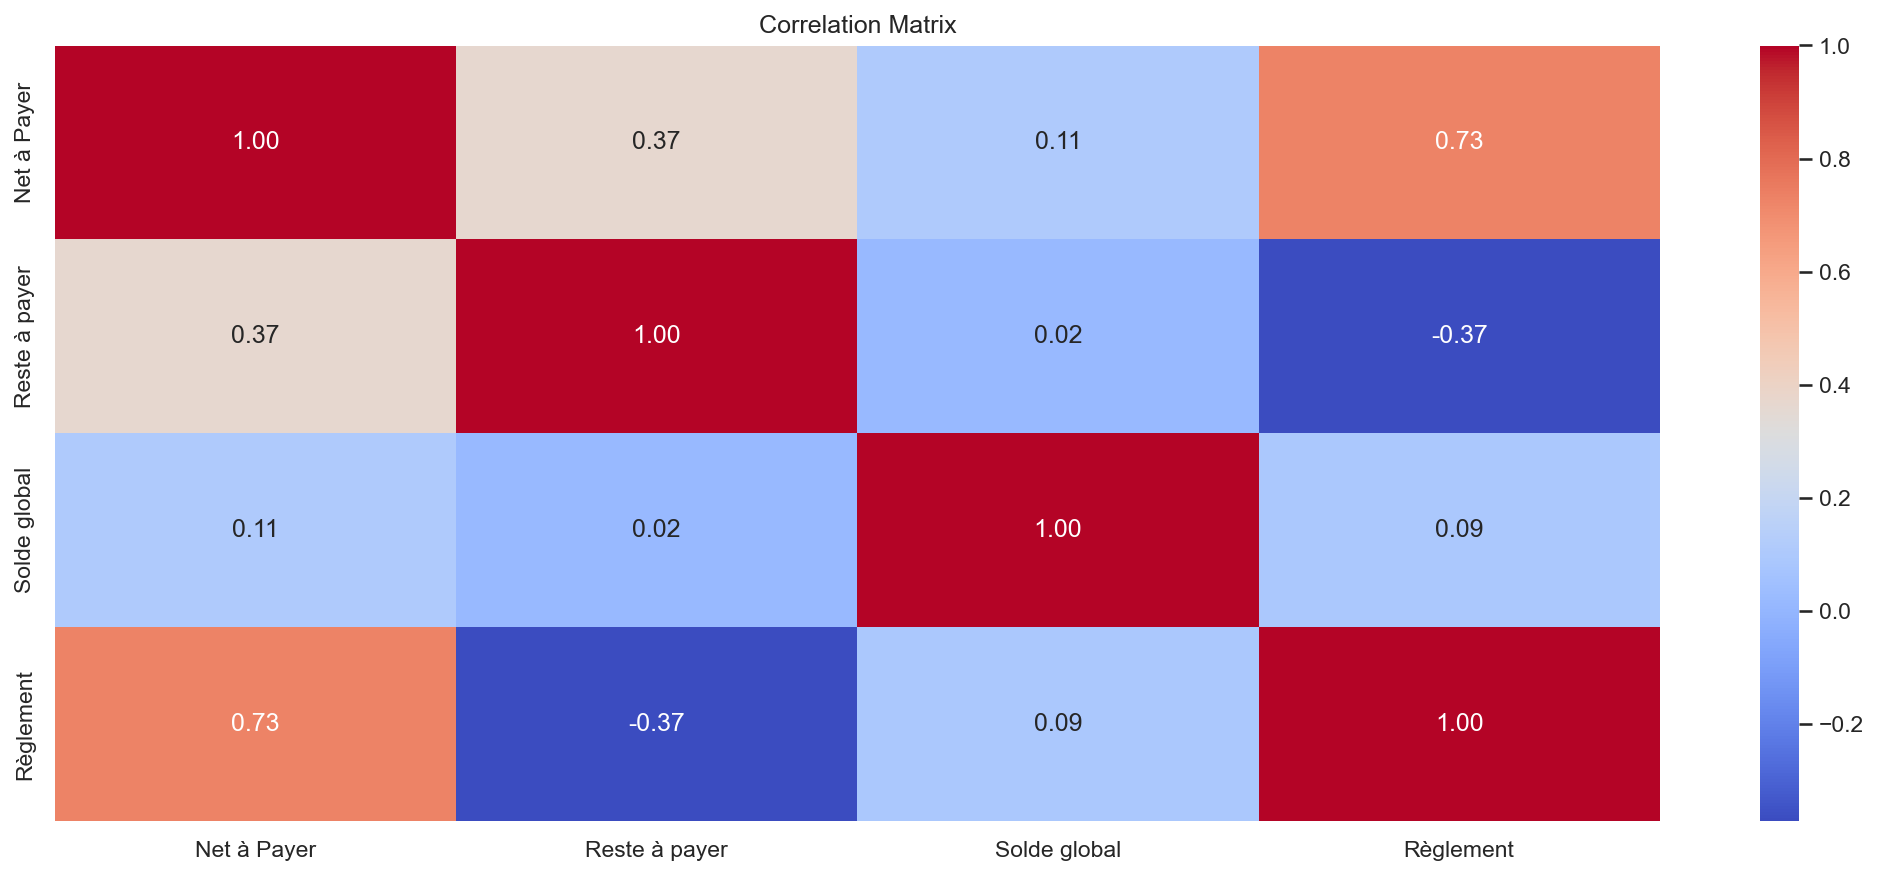

In [31]:
# 3) Correlation matrix (numerical)
num_cols = ['Net à Payer', 'Reste à payer', 'Solde global' , 'Règlement']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()


**Interpretation**

The correlation matrix helps identify how the main financial variables move together. Strong positive relationships are expected between invoiced amounts and payments, while weaker or more complex relationships with balances may reflect differences in settlement behavior across customers.


## Step 7 - Time Analysis


### Daily sales over time


In [32]:
df['day'] = df['Date'].dt.day_name()

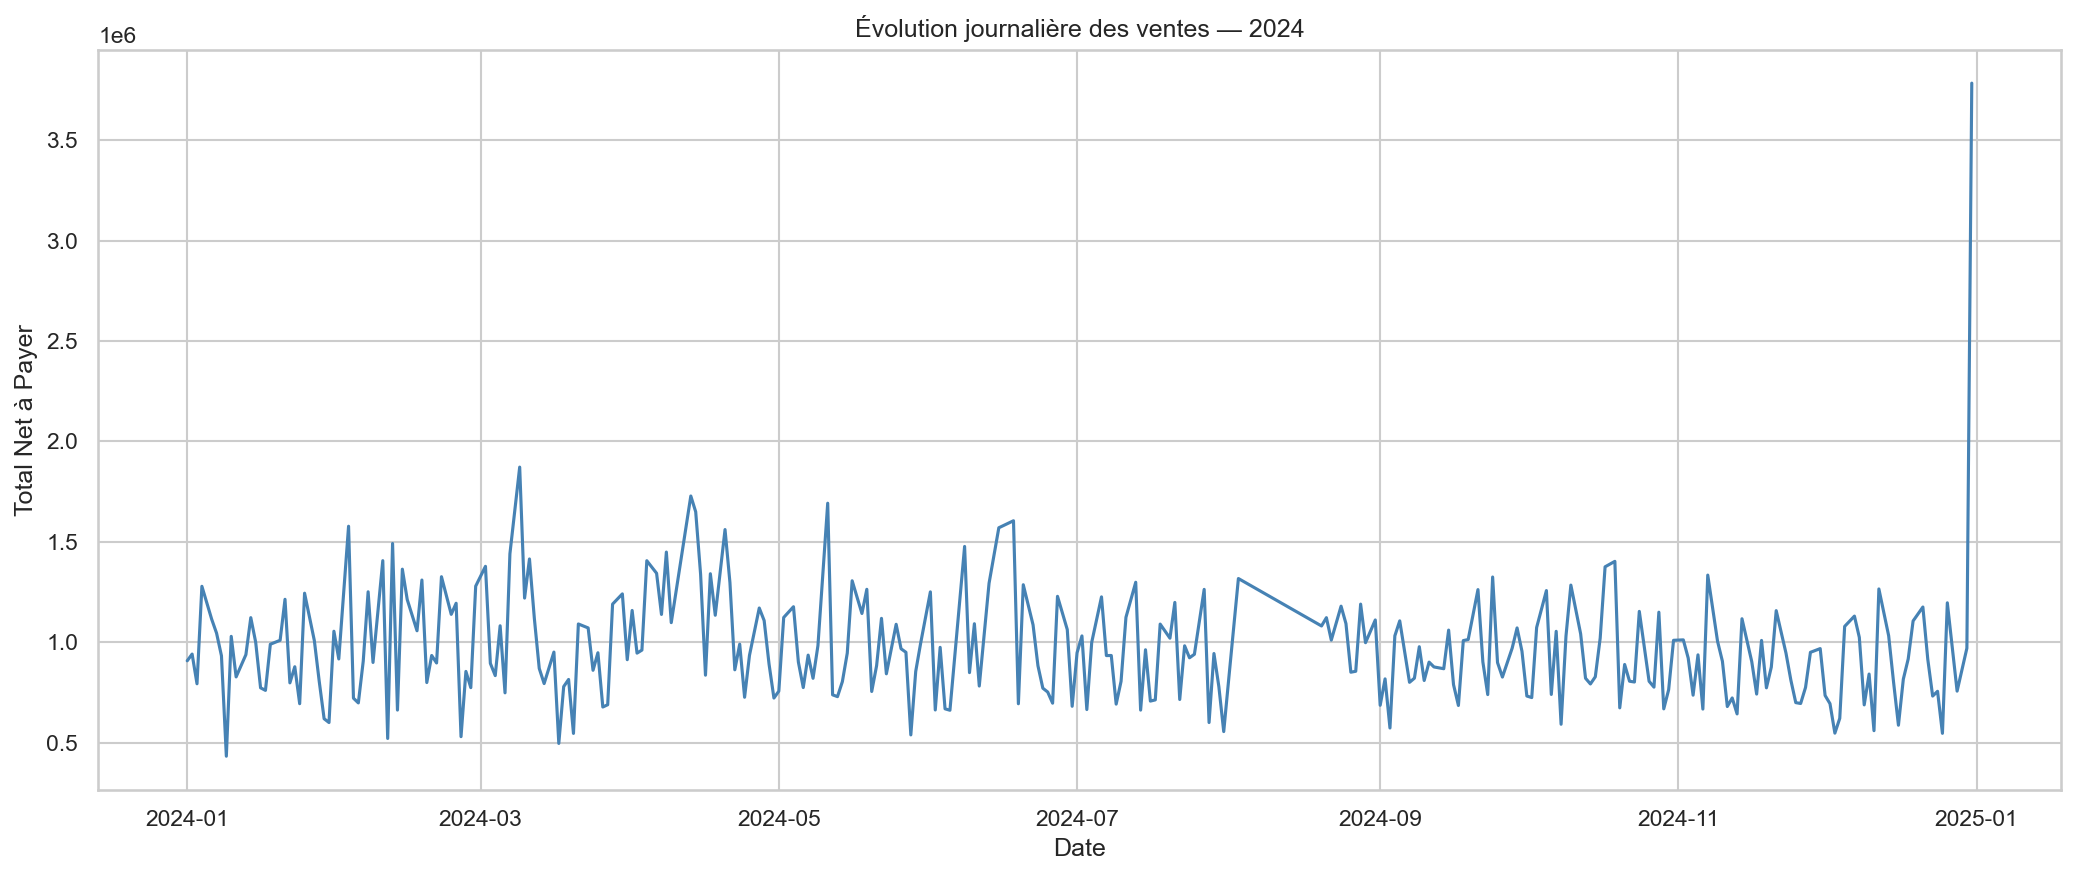

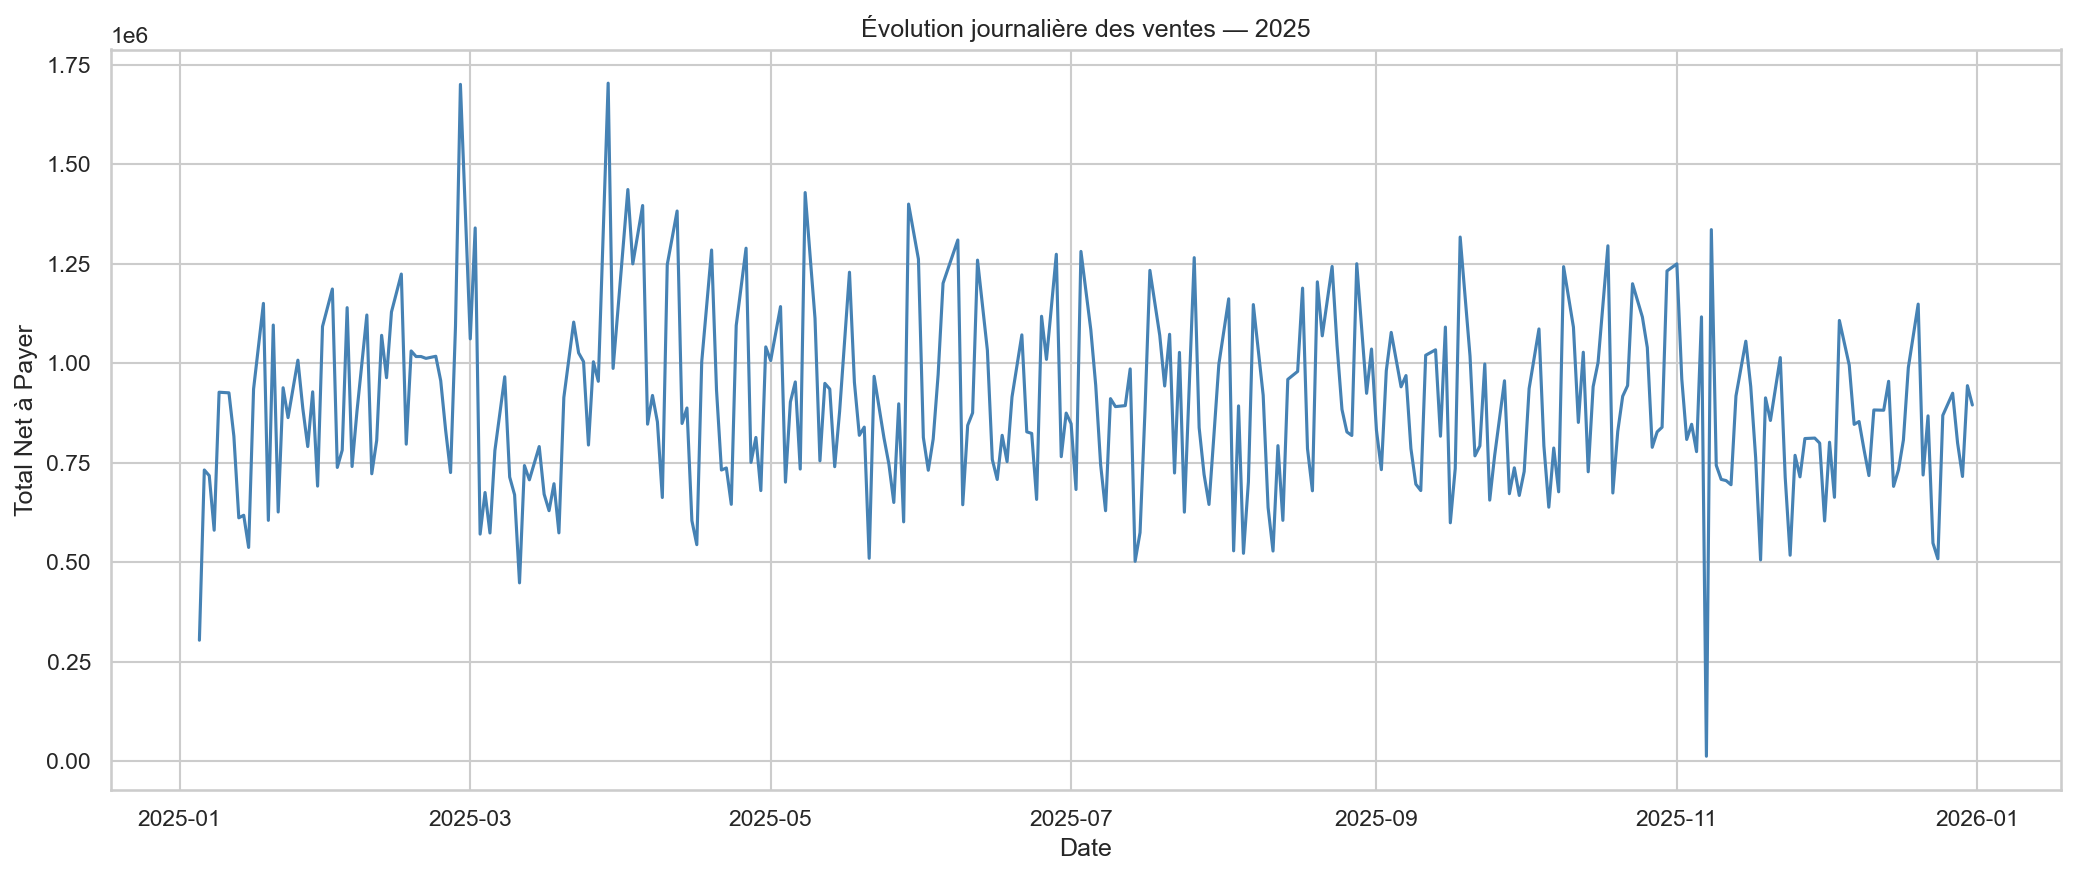

In [33]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df_time = df.dropna(subset=['Date'])

for year in [2024, 2025]:
    df_year = df_time[df_time['Date'].dt.year == year]
    daily_sales = df_year.groupby(df_year['Date'].dt.date)['Net à Payer'].sum()
    
    fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
    ax.plot(daily_sales.index, daily_sales.values, color='steelblue')
    ax.set_title(f'Évolution journalière des ventes — {year}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Net à Payer')
    plt.tight_layout()
    
    plt.show()


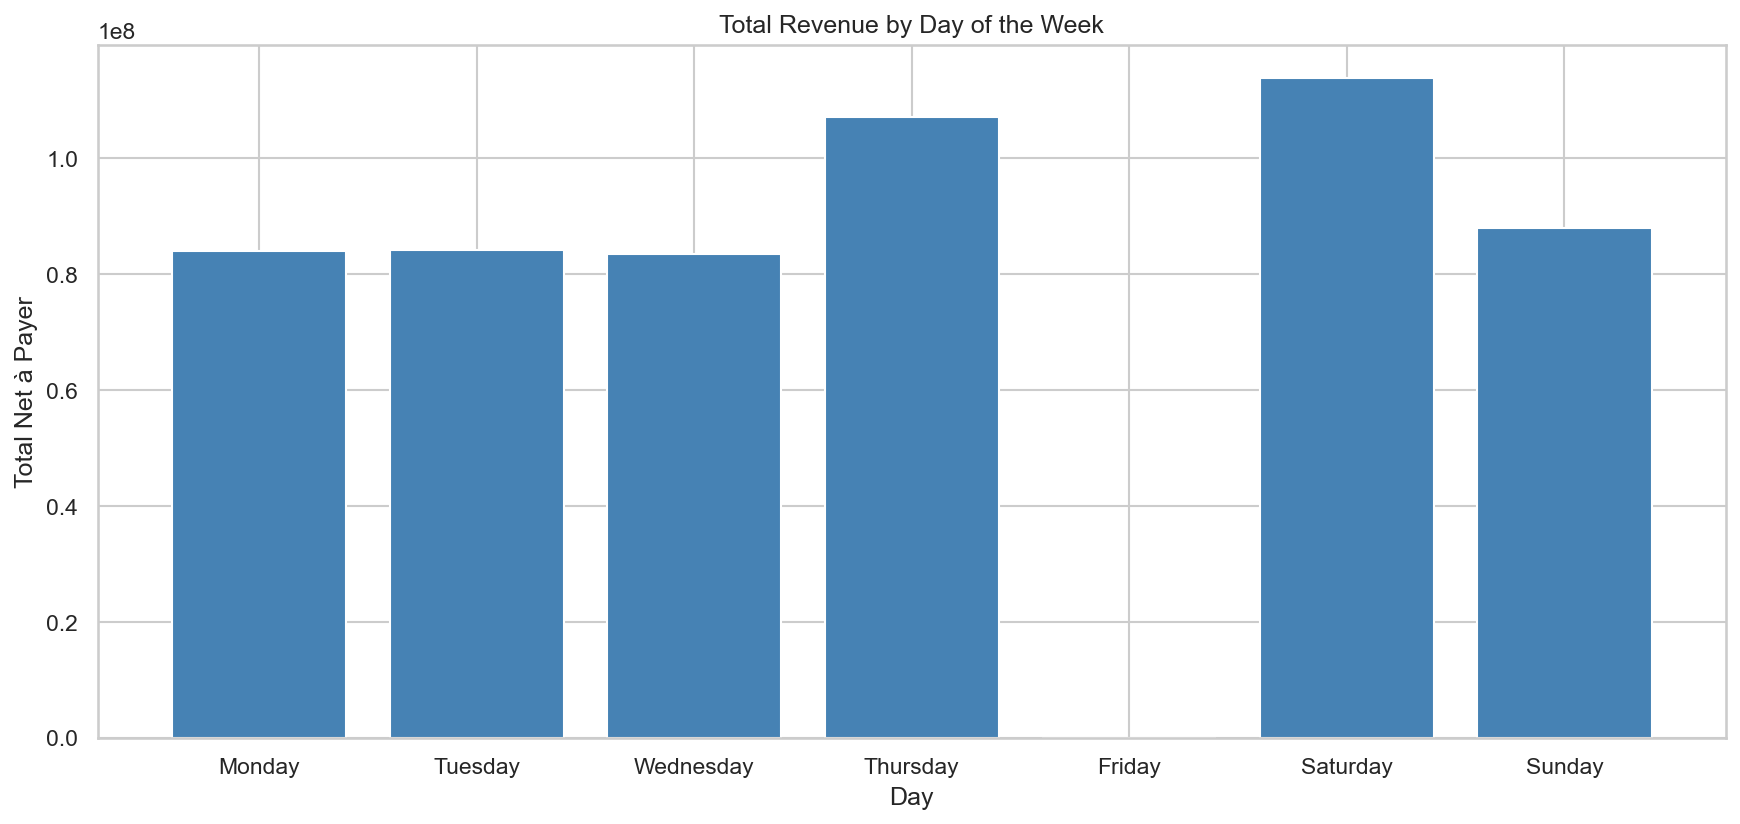

Highest revenue day: Saturday (113,910,720)


In [34]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_revenue = df.groupby('day')['Net à Payer'].sum().reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.bar(day_revenue.index, day_revenue.values, color='steelblue')
ax.set_title('Total Revenue by Day of the Week')
ax.set_xlabel('Day')
ax.set_ylabel('Total Net à Payer')

plt.show()

best_day = day_revenue.idxmax()
print(f'Highest revenue day: {best_day} ({day_revenue[best_day]:,.0f})')

**Interpretation**

The daily analysis highlights substantial short-term variability in sales. The fact that Saturday appears as the highest-revenue day suggests that sales intensity may depend on operating patterns, delivery cycles, or customer purchasing habits rather than being evenly distributed across the week.


### Monthly sales over time


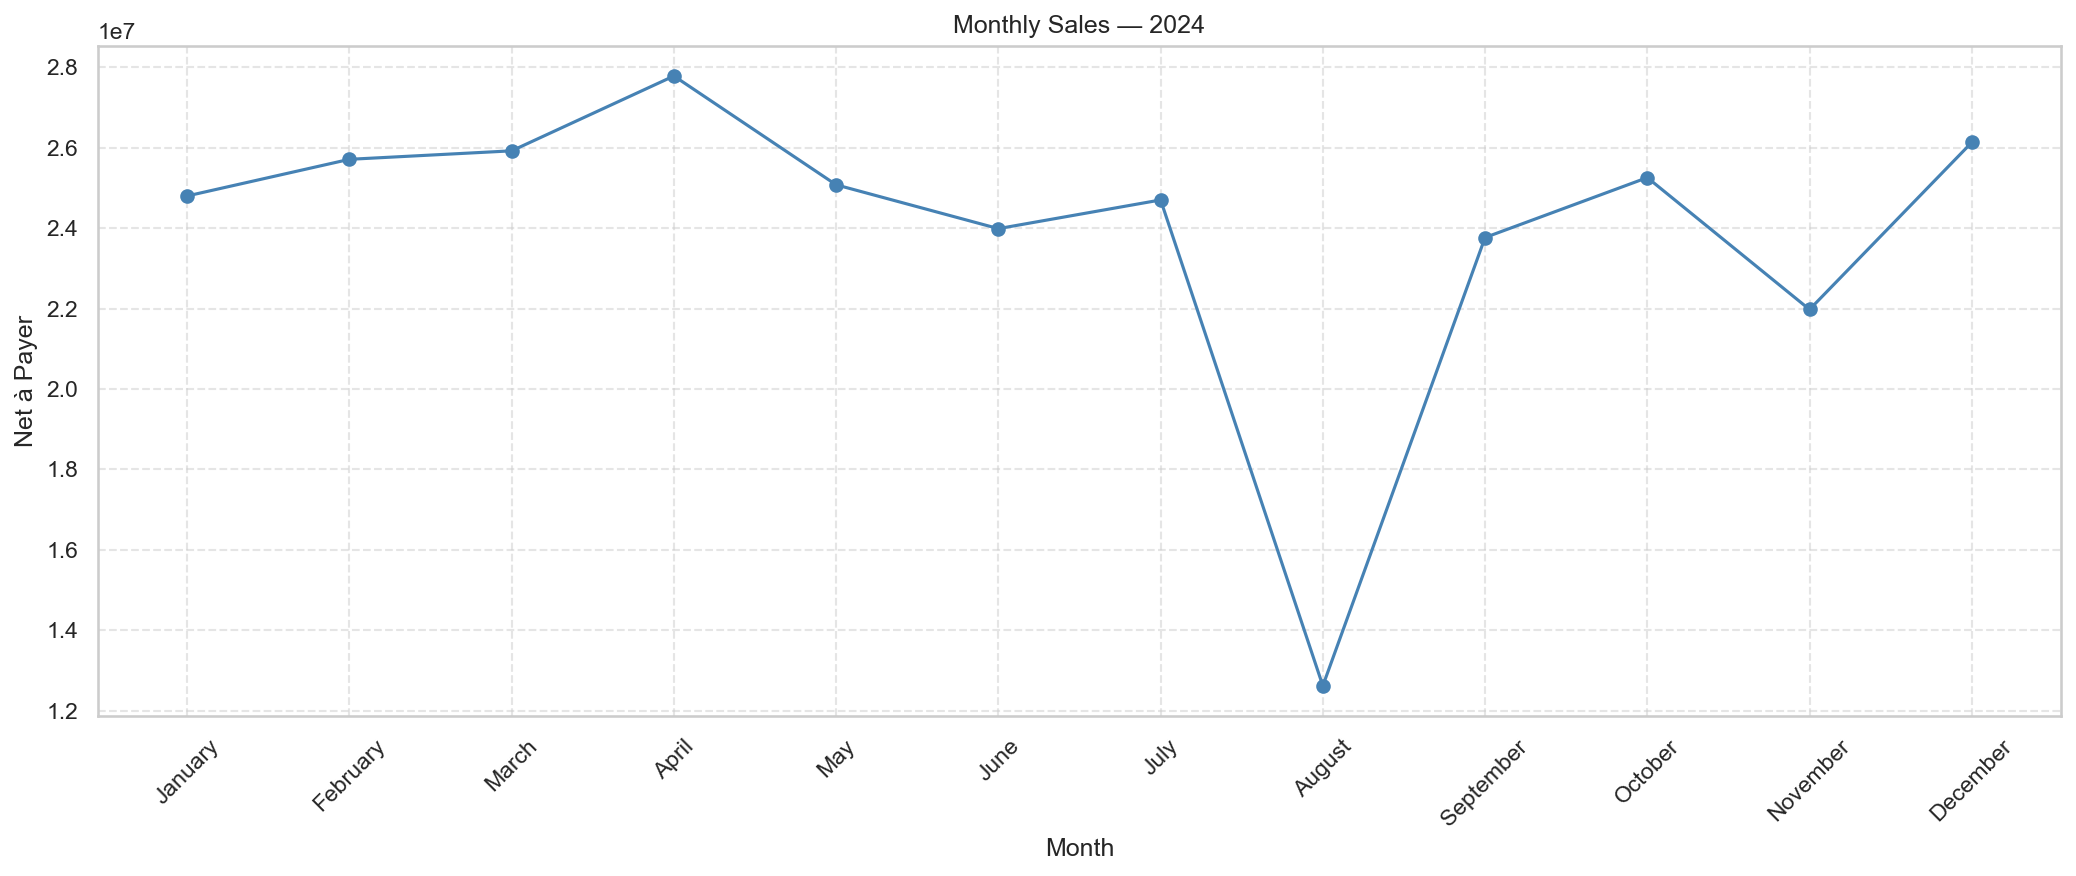

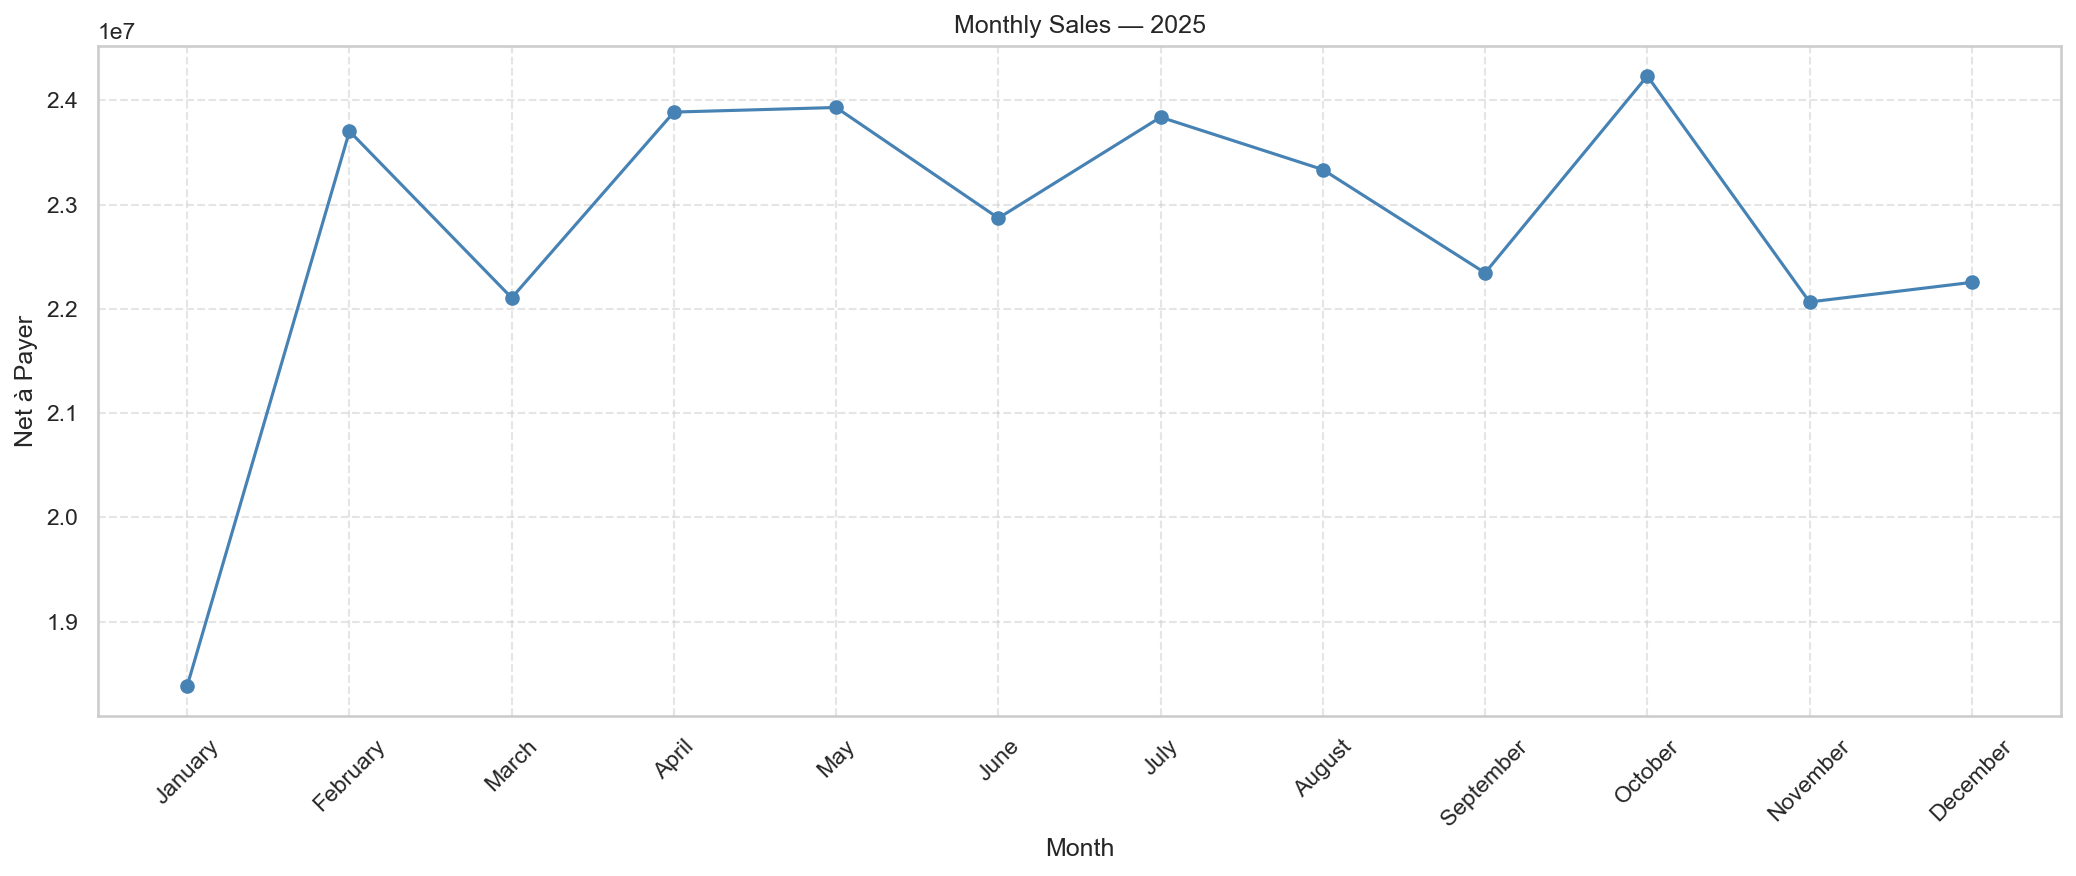

In [35]:
for year in [2024, 2025]:
    df_year = df[df['Année'] == year]
    monthly_sales = df_year.groupby('Mois_Nom')['Net à Payer'].sum()

    month_order = ['January','February','March','April','May','June',
                   'July','August','September','October','November','December']
    monthly_sales = monthly_sales.reindex([m for m in month_order if m in monthly_sales.index])

    fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
    ax.plot(monthly_sales.index, monthly_sales.values, marker='o', color='steelblue')
    ax.set_title(f'Monthly Sales — {year}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Net à Payer')
  
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

###  Seasonality (average sales per month across years)


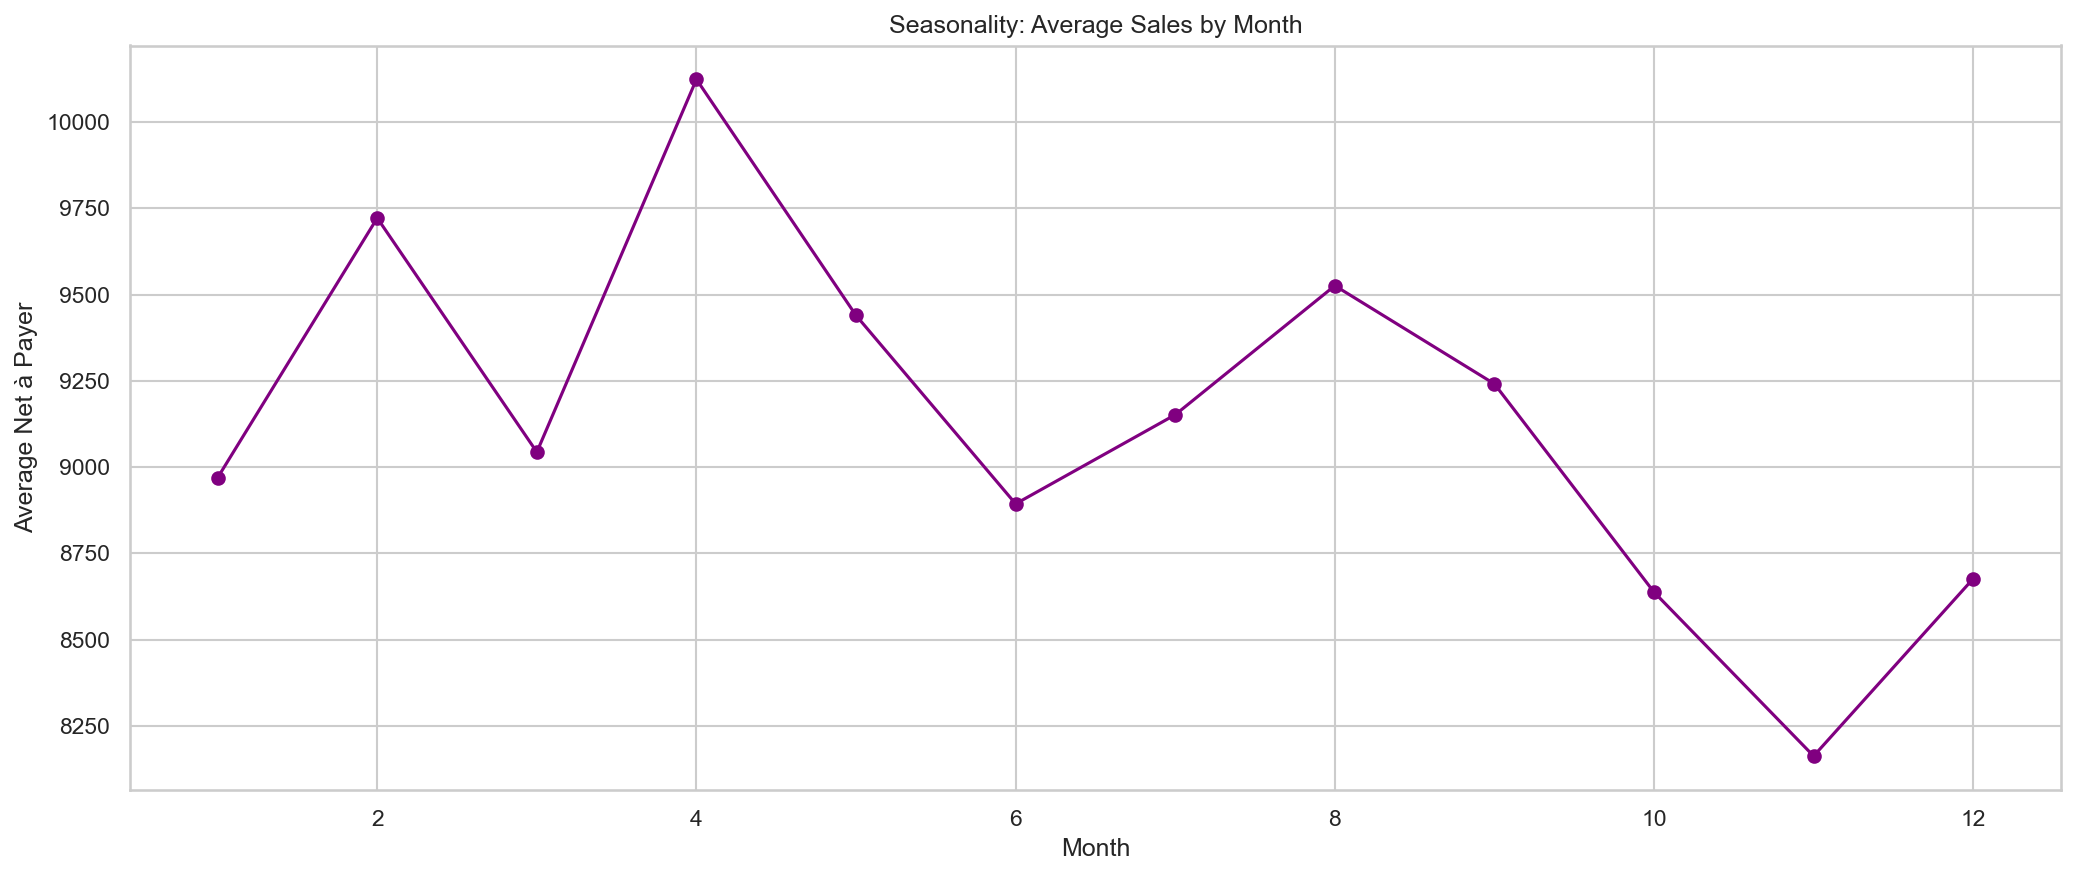

In [36]:
df_time['Month'] = df_time['Date'].dt.month
seasonality = df_time.groupby('Month')['Net à Payer'].mean().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.plot(seasonality.index, seasonality.values, marker='o', color='purple')
ax.set_title('Seasonality: Average Sales by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Net à Payer')
plt.tight_layout()
plt.show()


### Identify highest/lowest months


In [37]:
best_month = seasonality.idxmax()
worst_month = seasonality.idxmin()
print("Mois le plus fort (moyenne):", best_month)
print("Mois le plus faible (moyenne):", worst_month)


Mois le plus fort (moyenne): 4
Mois le plus faible (moyenne): 11


**Interpretation**

The monthly seasonality result indicates that month 4 has the strongest average sales level, while month 11 has the weakest. This difference suggests that business activity is not stable over the calendar year and that some periods are commercially stronger than others.


### monthly sum


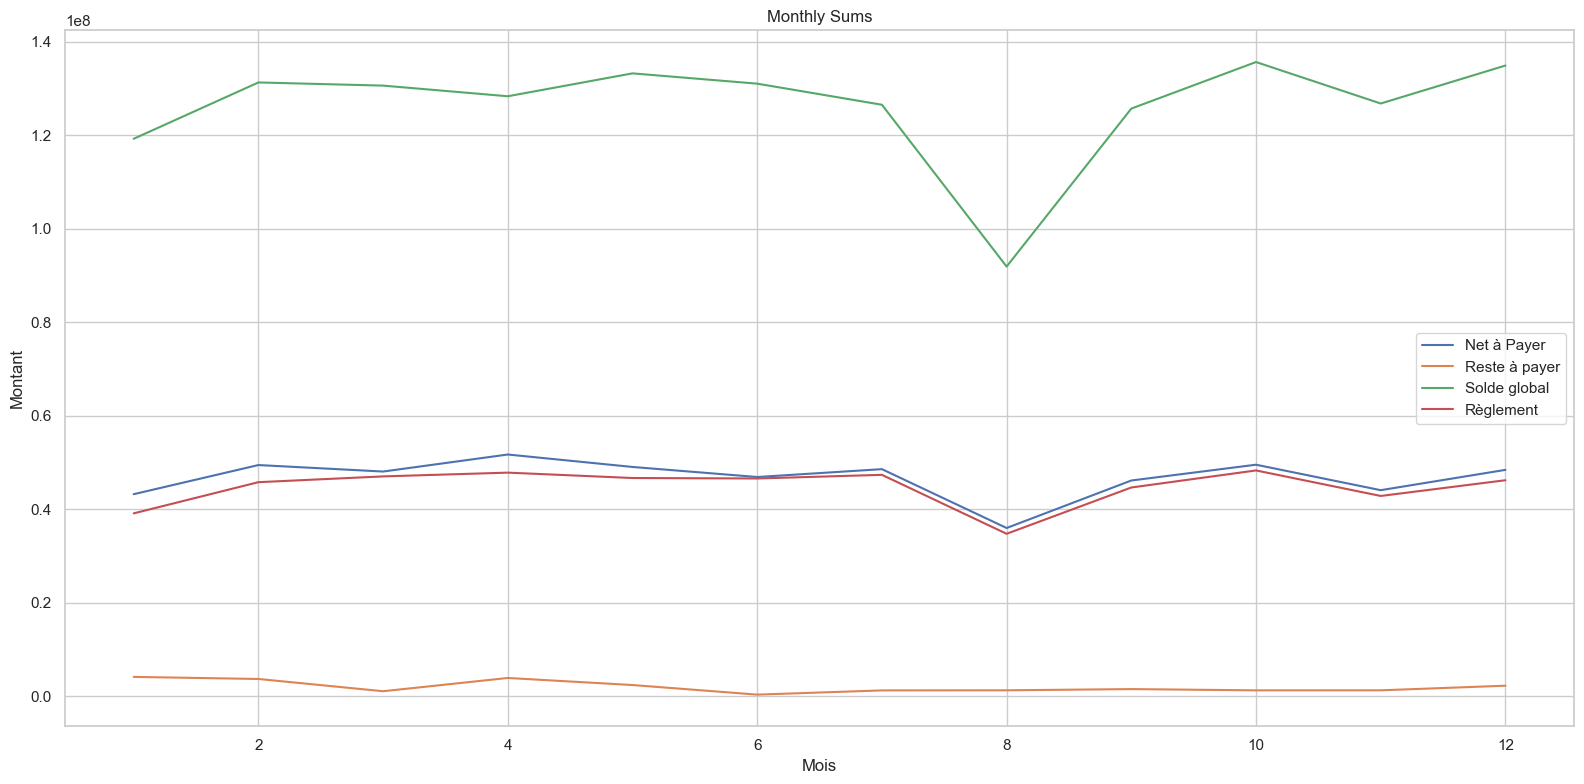

In [38]:
monthly = df.groupby('Mois')[num_cols].sum()
monthly.plot(figsize=(16, 8))
plt.title('Monthly Sums')
plt.xlabel('Mois')
plt.ylabel('Montant')
plt.tight_layout()
plt.show()


## Step 8 - Customer Analysis


### Number of transactions per client


In [39]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


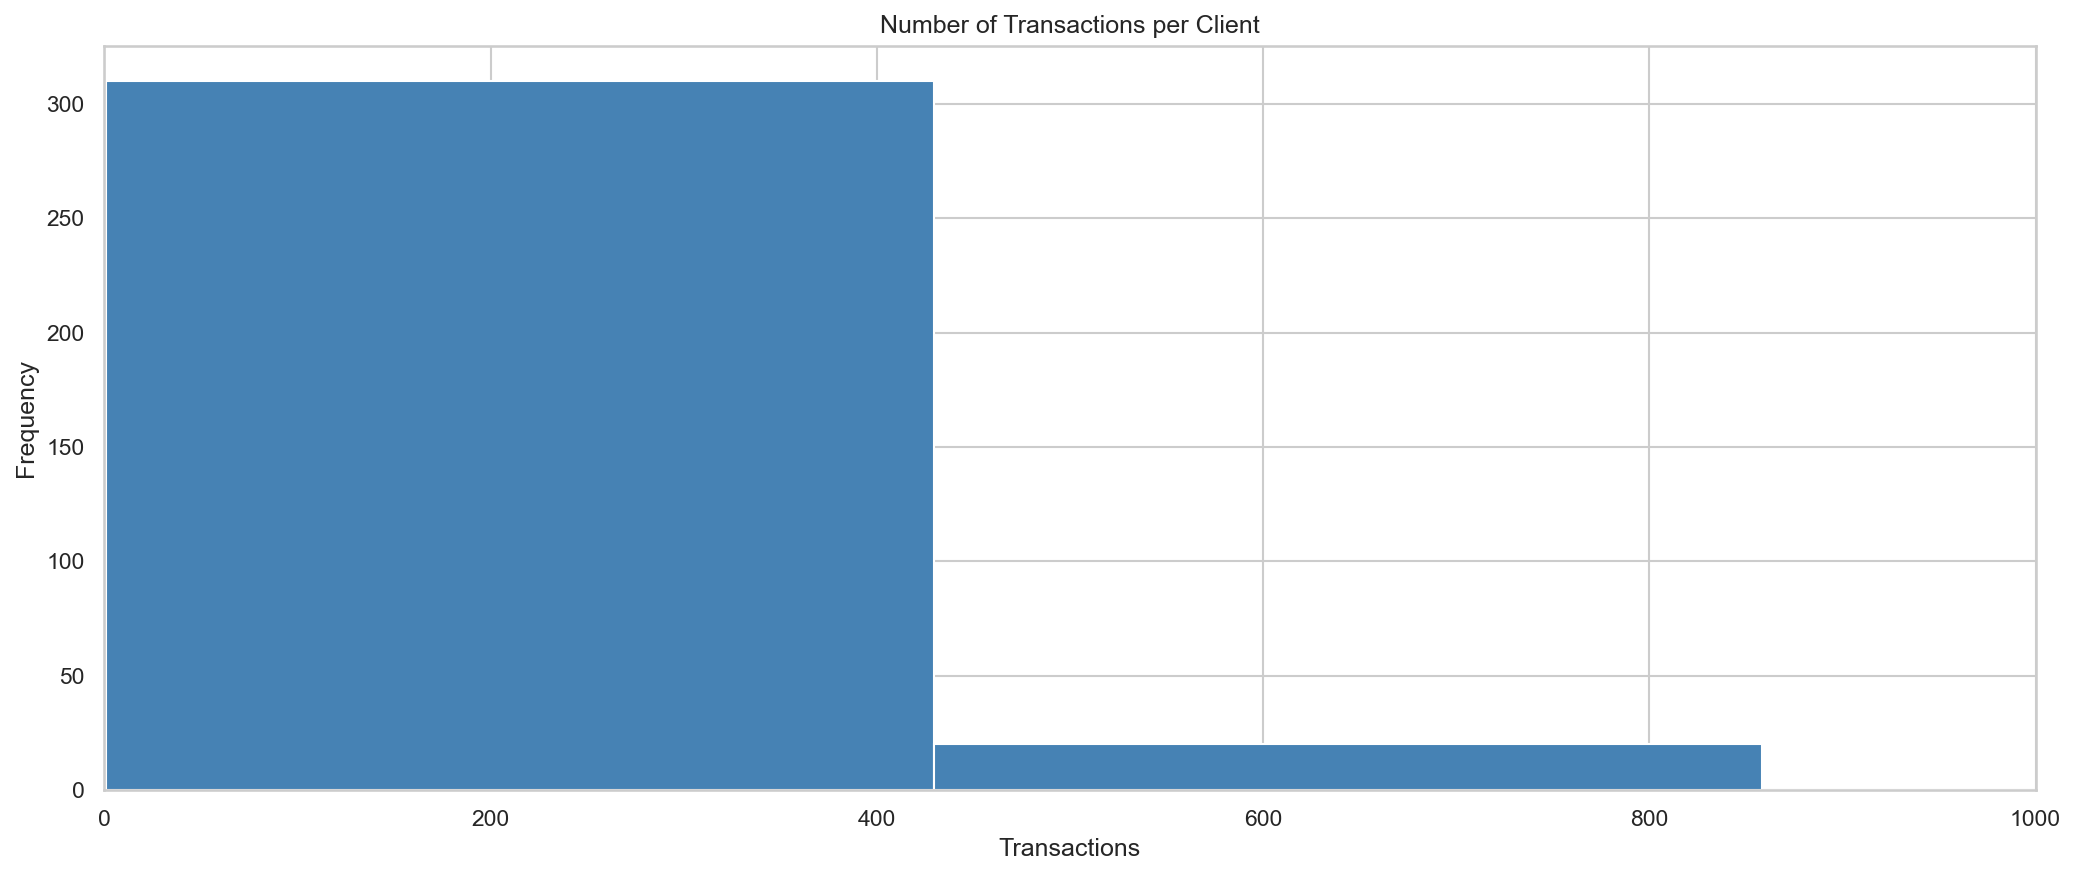

In [40]:
tx_per_client = df.groupby('Code Client')['Numéro de facture'].nunique()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(tx_per_client, bins=50, color='steelblue')
ax.set_title('Number of Transactions per Client')
ax.set_xlabel('Transactions')
ax.set_ylabel('Frequency')
plt.xlim(0,1000)
plt.tight_layout()
plt.show()


### Total spending per client


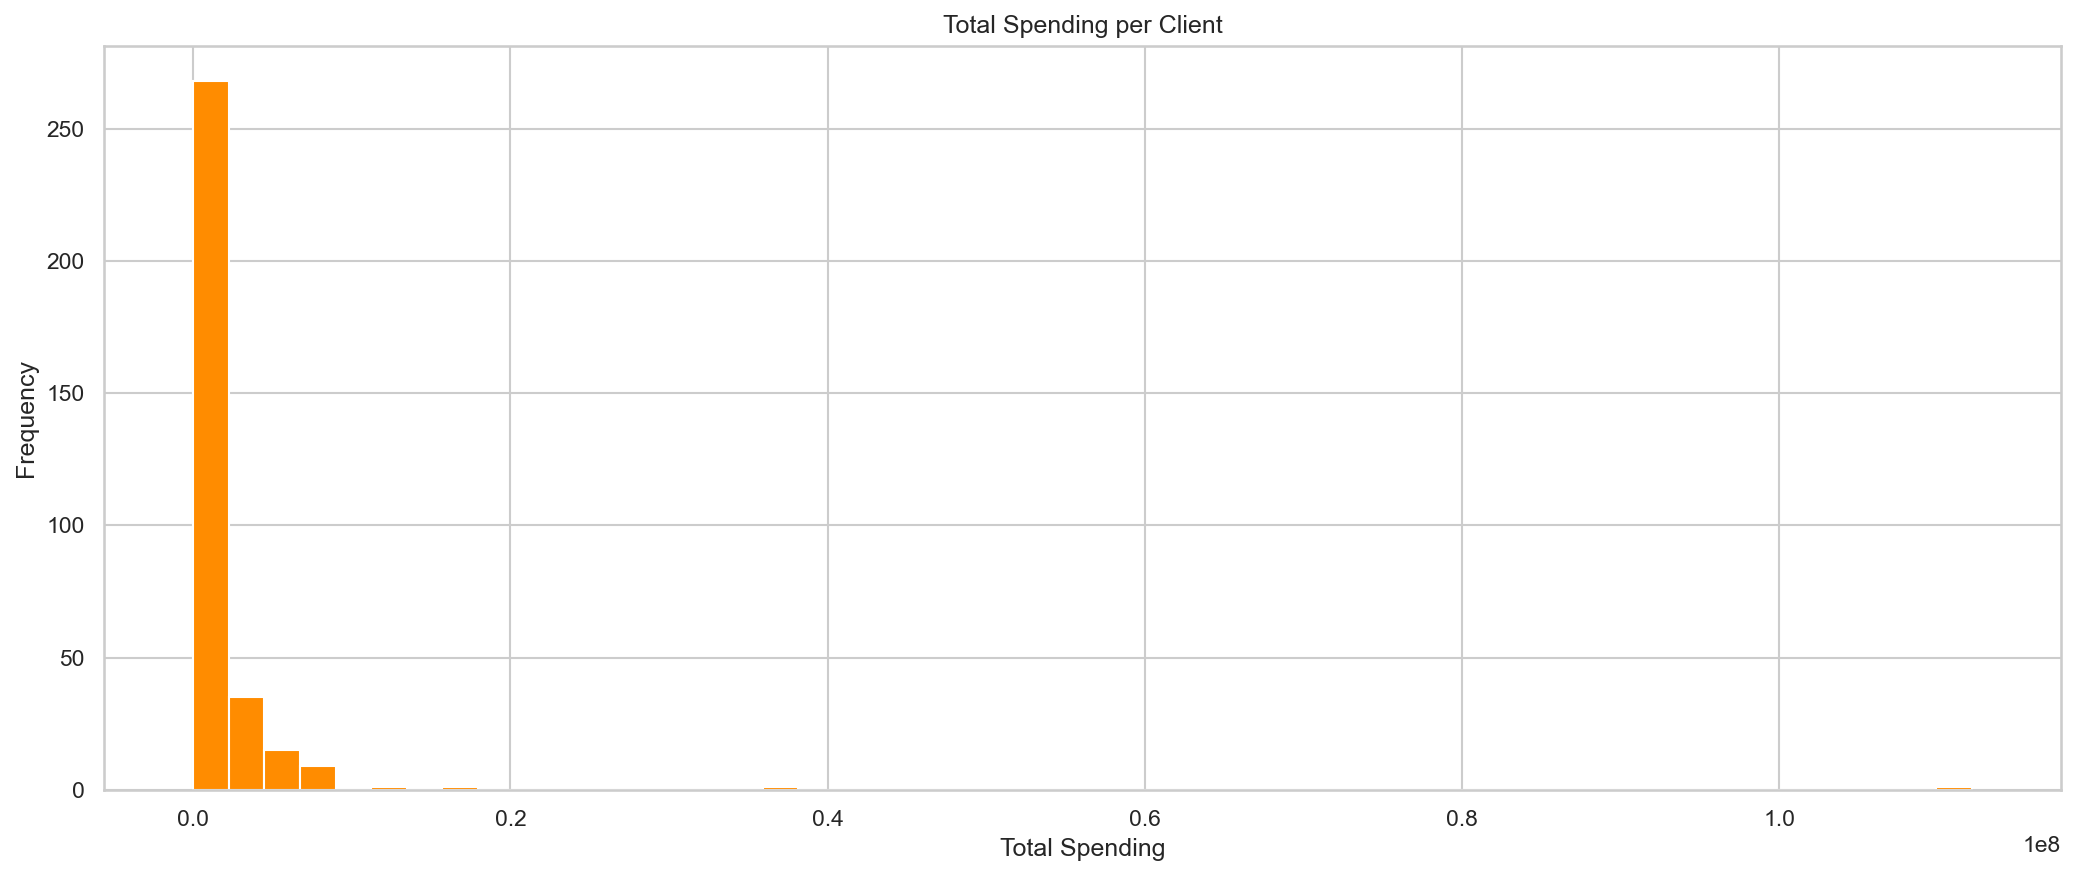

In [41]:
spend_per_client = df.groupby('Code Client')['Net à Payer'].sum()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(spend_per_client, bins=50, color='darkorange')
ax.set_title('Total Spending per Client')
ax.set_xlabel('Total Spending')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


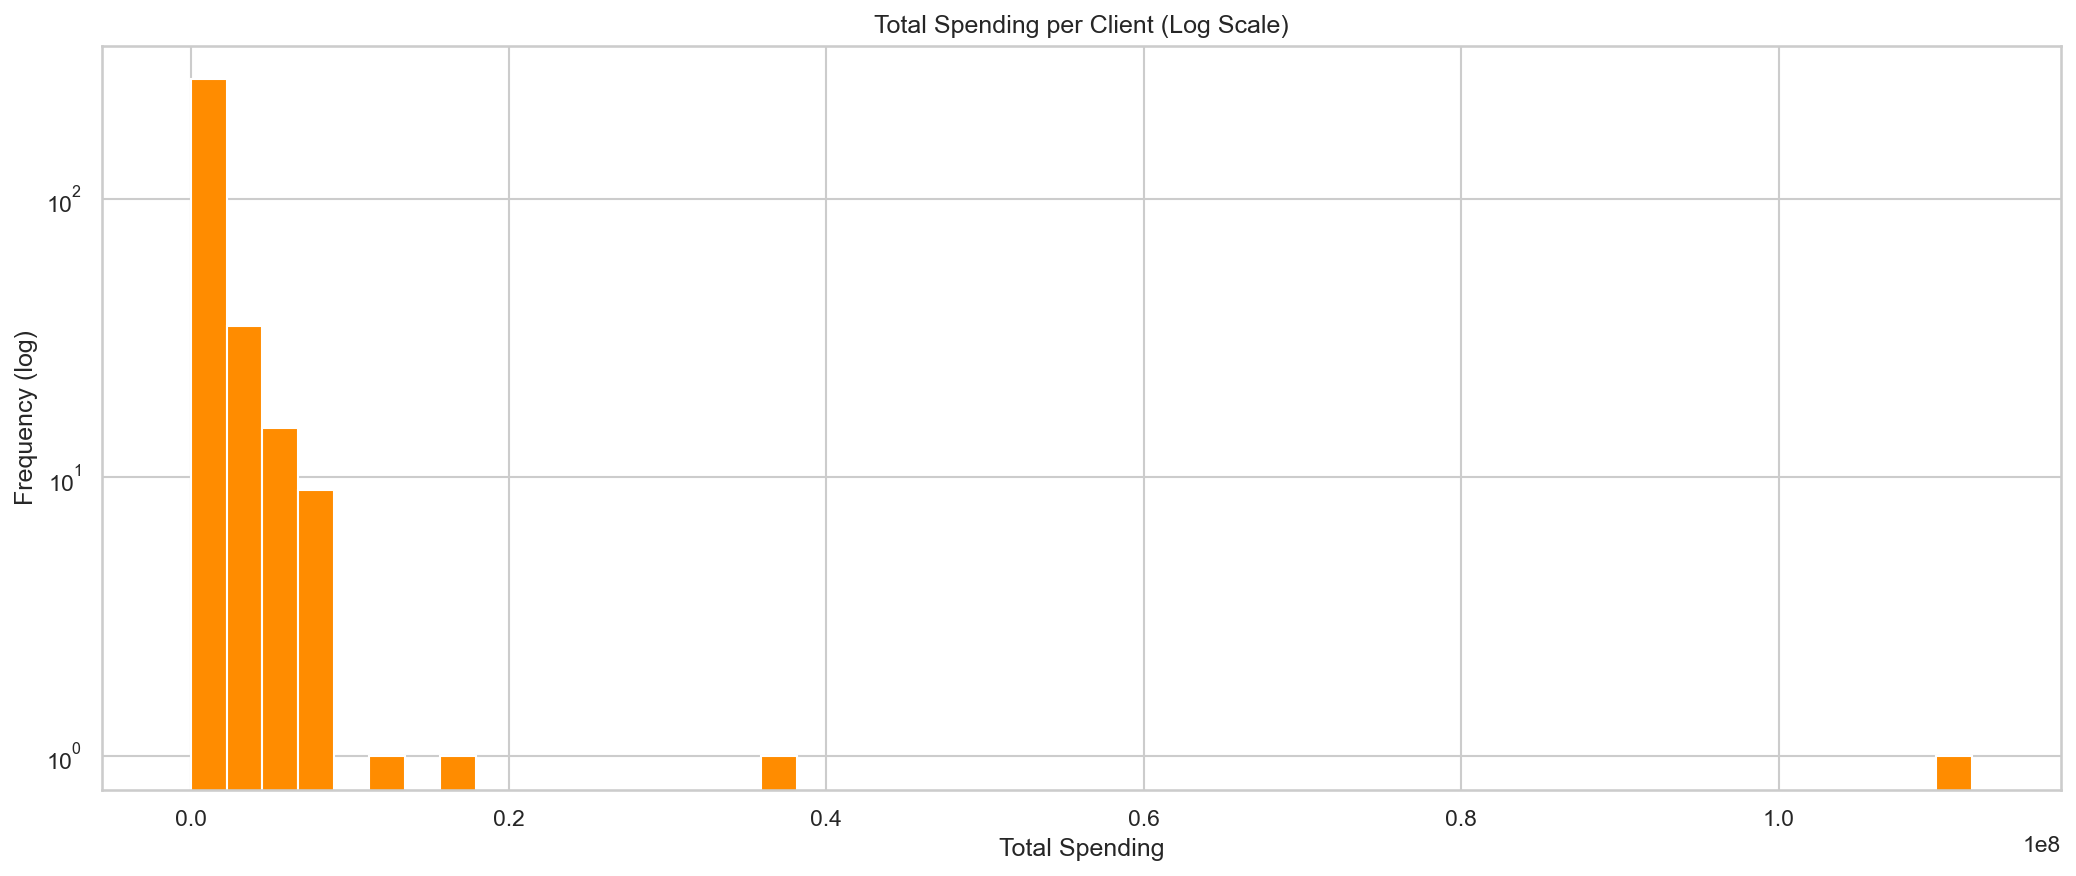

In [42]:
# Log scale
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.hist(spend_per_client, bins=50, color='darkorange', log=True)
ax.set_title('Total Spending per Client (Log Scale)')
ax.set_xlabel('Total Spending')
ax.set_ylabel('Frequency (log)')
plt.tight_layout()
plt.show()

### Top clients by revenue


Top 10 clients by revenue:
Code Client
AA000002   112,169,699.90
BO000021    38,089,280.80
NO000002    17,877,935.34
AH000004    13,260,933.26
BE000004     8,700,934.25
ME000005     8,649,519.97
AB000005     8,387,229.83
MI000004     8,348,217.54
BOU00001     8,198,725.65
GU000003     7,775,976.99
Name: Net à Payer, dtype: float64


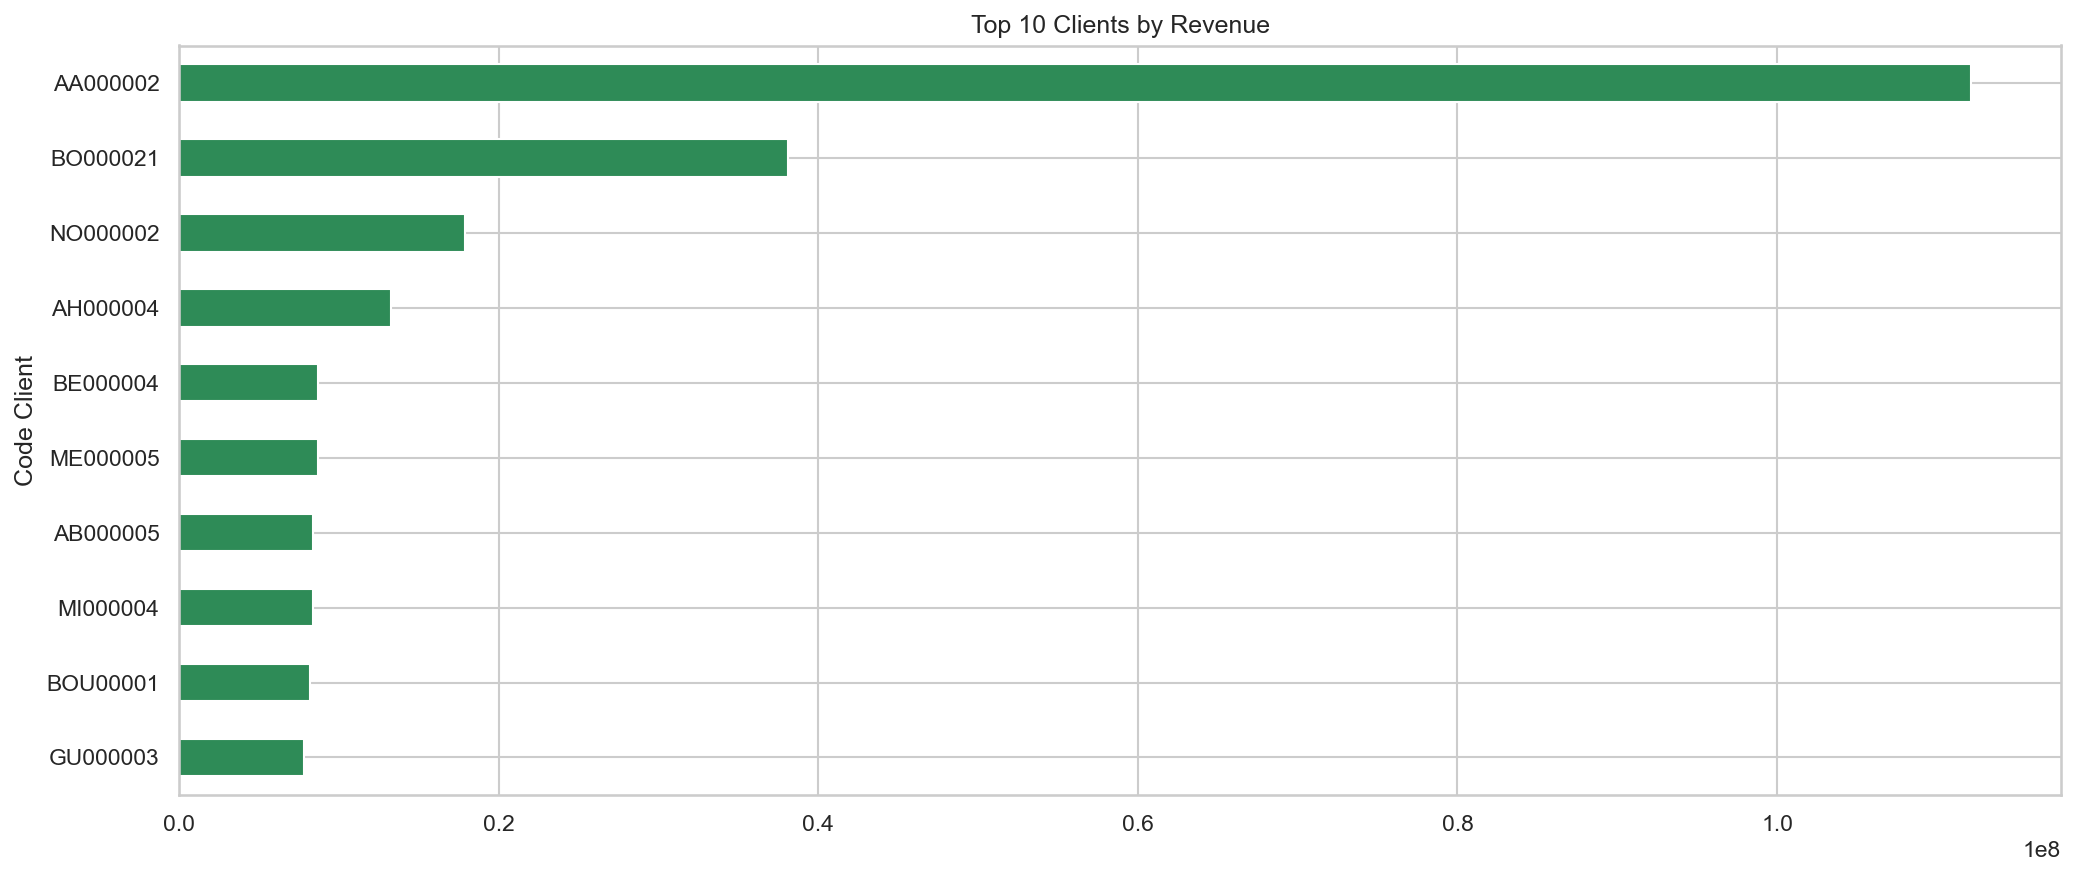

In [43]:
# 3) Top clients by revenue
top_clients = spend_per_client.sort_values(ascending=False).head(10)
print("Top 10 clients by revenue:")
print(top_clients)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
top_clients.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Top 10 Clients by Revenue')
plt.tight_layout()
plt.show()


**Interpretation**

The top revenue ranking confirms a very strong concentration of sales. Client `AA000002` is far above the rest, followed by a smaller set of other major contributors. This supports the idea that the business has a group of VIP clients whose retention is likely critical for total revenue stability.


### Top clients by transactions


Top 10 clients by number of transactions:
Code Client
AA000002    21437
HA000009      753
IS000003      750
ME130001      698
AB000005      679
LA000001      678
AH000004      652
TO000003      640
NA000002      621
BO000010      618
Name: Numéro de facture, dtype: int64


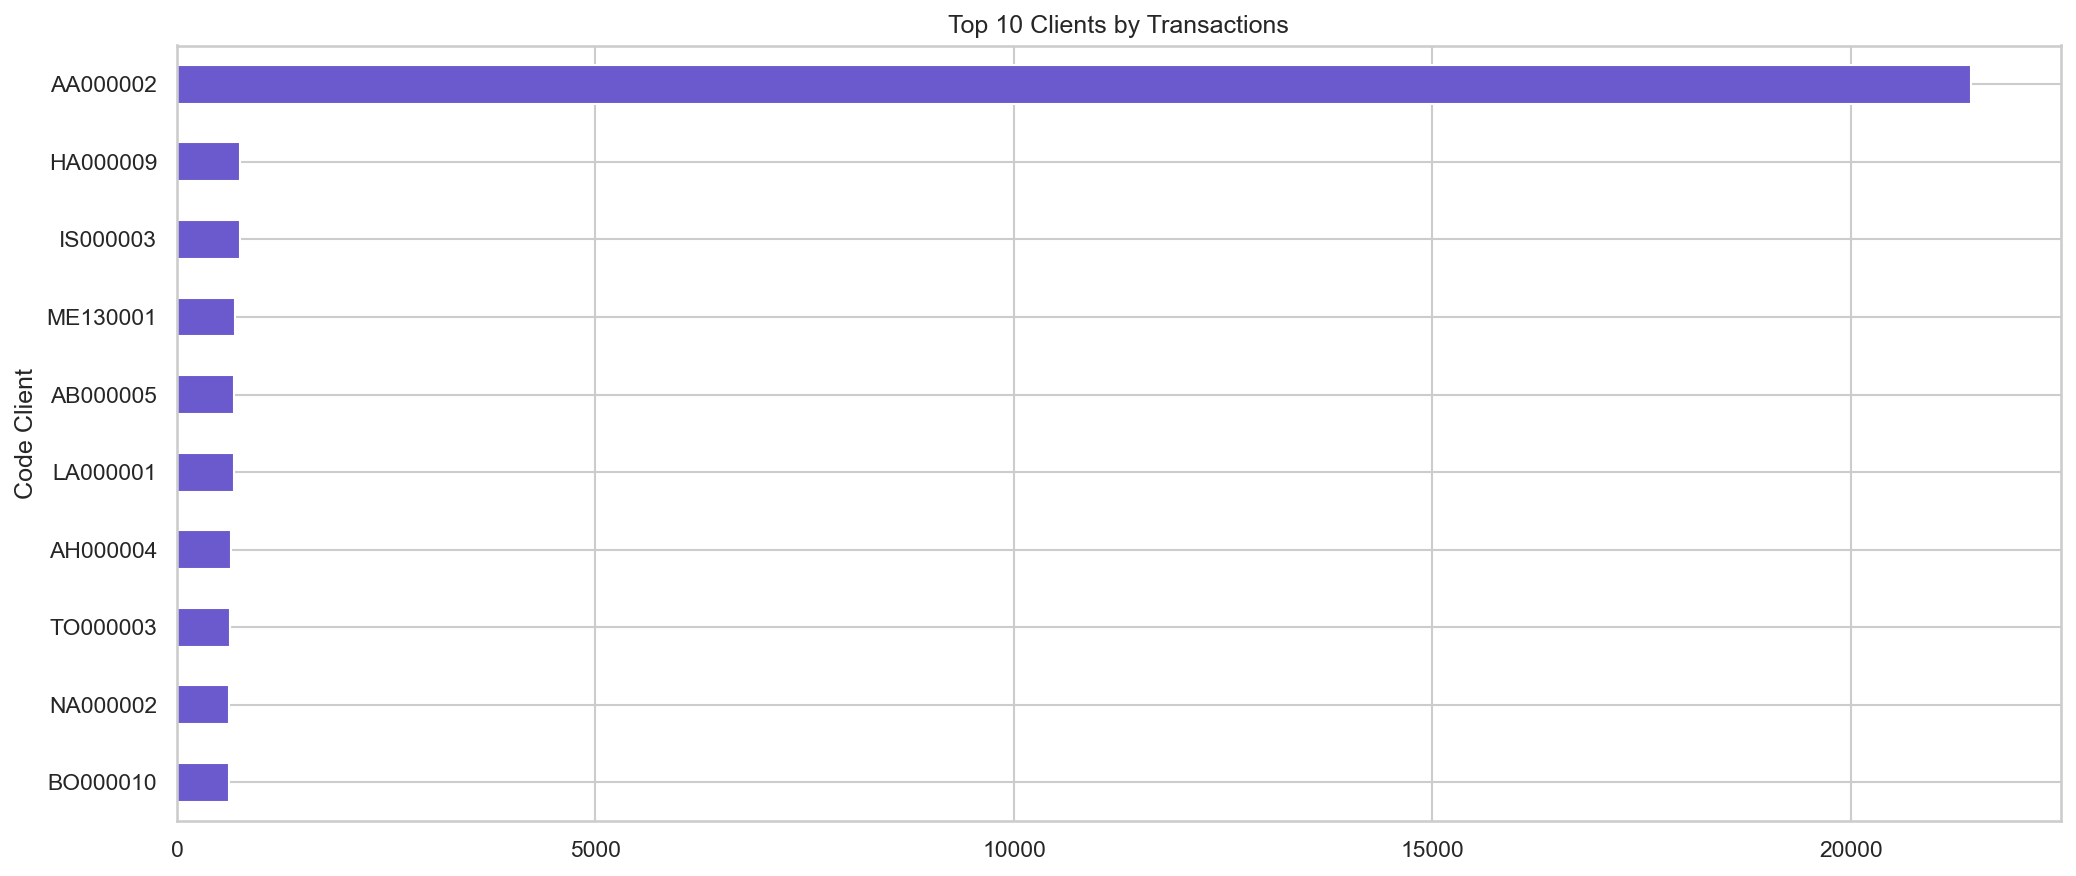

In [44]:
# 4) Top clients by transactions
top_tx = tx_per_client.sort_values(ascending=False).head(10)
print("Top 10 clients by number of transactions:")
print(top_tx)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
top_tx.sort_values().plot(kind='barh', ax=ax, color='slateblue')
ax.set_title('Top 10 Clients by Transactions')
plt.tight_layout()
plt.show()


**Interpretation**

The top transaction-count ranking shows that the most active clients are not always the same as the highest-revenue clients. This distinction matters because some customers generate value through purchase frequency, while others generate value through larger transaction amounts.


### Inactive clients (bought in 2024 but not in 2025)


In [45]:
# 5) Inactive clients (bought in 2024 but not in 2025)
df['Année'] = pd.to_datetime(df['Date'], errors='coerce').dt.year
clients_2024 = set(df[df['Année'] == 2024]['Code Client'])
clients_2025 = set(df[df['Année'] == 2025]['Code Client'])
inactive_clients = clients_2024 - clients_2025
print("Inactive clients:", len(inactive_clients))
print(list(inactive_clients)[:20])


Inactive clients: 74
['BO000013', 'MB000001', 'TA000004', 'AZ000004', 'YO000002', 'MO000003', 'AB000004', 'AY000002', 'ME000004', 'BO000024', 'DJ000013', 'HA000032', 'KA000009', 'AM000003', 'BO000027', 'SI000005', 'DJ000011', 'MO000005', 'EC000002', 'AM000014']


**Interpretation**

The presence of 74 inactive clients, defined as customers who bought in 2024 but not in 2025, suggests that customer retention is not perfect. This result is important because it points to possible churn or reduced engagement, which should be considered in later segmentation and strategy recommendations.


### Top Clients


In [46]:
top_net = df.groupby(['Code Client'])['Net à Payer'].sum().sort_values(ascending=False).head(10)
top_reg = df.groupby(['Code Client'])['Règlement'].sum().sort_values(ascending=False).head(10)
top_reste = df.groupby(['Code Client'])['Reste à payer'].sum().sort_values(ascending=False).head(10)

print("Top Net à Payer")
print(top_net)
print("Top Réglement")
print(top_reg)
print("Top Reste à payer")
print(top_reste)


Top Net à Payer
Code Client
AA000002   112,169,699.90
BO000021    38,089,280.80
NO000002    17,877,935.34
AH000004    13,260,933.26
BE000004     8,700,934.25
ME000005     8,649,519.97
AB000005     8,387,229.83
MI000004     8,348,217.54
BOU00001     8,198,725.65
GU000003     7,775,976.99
Name: Net à Payer, dtype: float64
Top Réglement
Code Client
AA000002   111,408,020.82
BO000021    25,937,773.80
NO000002    16,172,446.97
AH000004    13,038,435.58
ME000005     8,593,524.64
BE000004     8,541,488.43
AB000005     8,372,610.14
MI000004     8,324,088.09
BOU00001     8,179,062.93
GU000003     7,774,928.73
Name: Règlement, dtype: float64
Top Reste à payer
Code Client
BO000021   12,151,507.00
NO000002    1,705,488.37
AL000002    1,515,890.79
AM000015    1,169,189.31
KE000001      977,653.39
AA000002      761,679.08
RA000005      720,605.00
GU000002      519,757.01
HA000013      410,561.45
DA000005      362,469.88
Name: Reste à payer, dtype: float64


**Interpretation**

The final customer ranking confirms several key patterns at once: a small number of clients dominate `Net ? Payer`, payment rankings are closely aligned with revenue rankings, and the highest outstanding balances are concentrated among specific accounts. Overall, the customer base is clearly heterogeneous, which supports the use of RFM-style segmentation in the next stage of the project.
